# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuição Física**

---

# **Aula 4 — Modelagem matemática do CVRP (Parte 2)**
## **Sprint 1 — Experimentos computacionais**
**Prof. Marcello Congro (marcellocongro@puc-rio.br)**

---

## 🎯 Estrutura deste notebook

**PARTE I — Modelo (idêntico ao notebook da aula)**
1. Ambiente e instância
2. Parâmetros logísticos (frota heterogênea)
3. Construção do modelo matemático
4. Pós-processamento, validação e **mapa interativo**

**PARTE II — Sprint 1: experimentos computacionais**

| # | Experimento | Tipo |
|---|---|---|
| E1 | Utilização e remoção da formulação MTZ | 🔴 obrigatório |
| E2 | Análise do gap × time limit | 🟢 opcional |
| E3 | Comparação entre solvers | 🔴 obrigatório |
| E4 | Velocidade média × tempo de serviço | 🟢 opcional |
| E5 | Variação do custo fixo do VUC | 🔴 obrigatório |
| E6 | Qualidade da solução obtida (tolerância de gap) | 🟢 opcional |

---

## ⚠️ Duas coisas importantes antes de começar

**1. O modelo NÃO foi alterado.** As restrições são exatamente as mesmas do notebook
original: grau, balanço no depósito, saída única por tipo, capacidade agregada,
fluxo por tipo, MTZ e ativação de veículo. O que mudou é a *infraestrutura em volta*:
o modelo agora é construído por uma **função** (`build_model`), o que permite
reconstruí-lo com parâmetros diferentes a cada experimento.

Por que isso é obrigatório: no Pyomo, `Objective(rule=...)` é avaliada **uma única
vez**, na construção. A expressão guardada contém os *números*, não o dicionário.
Fazer `f["VUC"] = 900` depois e chamar `solver.solve(model)` de novo devolve
exatamente o mesmo custo — o experimento de sensibilidade não sai do lugar.
A célula (17) tem um `assert` que prova que a função reproduz o modelo original.

**2. Fluxo de trabalho entre instâncias.** Tudo aqui foi calibrado para rodar em
**C1** (10 clientes, segundos). C2, C3 e C4 (25, 40 e 60 clientes) crescem de forma
combinatória — o MTZ sozinho adiciona ~n² restrições. Cada experimento tem um bloco
de configuração no topo com os parâmetros de esforço; valide em C1, depois
aumente os limites e rode as demais.

---
# **PARTE I — Modelo**

In [1]:
# =====================================================
# (1) PREPARAÇÃO DO AMBIENTE COMPUTACIONAL
# =====================================================

# Nesta disciplina, o solver é apenas o "motor" de otimização.
# O que determina a qualidade/realismo da solução é o MODELO matemático.

# Instalamos TRÊS solvers para o experimento E3:
#   - CBC     : open-source, referência "sempre disponível"
#   - HiGHS   : open-source moderno, costuma ser bem mais rápido que o CBC
#   - Gurobi  : comercial (licença WLS acadêmica)
#
# E também o folium, para os mapas interativos.

# Instala no próprio kernel e funciona em Windows, Linux ou Colab.
# PuLP fornece um executável local do CBC no Windows.
%pip install -q pyomo highspy gurobipy folium pulp

# Pergunta:
# um modelo mais realista será mais fácil ou mais difícil de resolver?

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package coinor-libcoinutils3v5:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../0-coinor-libcoinutils3v5_2.11.4+repack1-2_amd64.deb ...
Unpacking coinor-libcoinutils3v5:amd64 (2.11.4+repack1-2) ...
Selecting previously unselected package coinor-libosi1v5:amd64.
Preparing to unpack .../1-coinor-libosi1v5_0.108.6+repack1-2_amd64.deb ...
Unpacking coinor-libosi1v5:amd64 (0.108.6+repack1-2) ...
Selecting previously unselected package coinor-libclp1.
Preparing to unpack .../2-coinor-libclp1_1.17.5+repack1-1_amd64.deb ...
Unpacking coinor-libclp1 (1.17.5+repack1-1) ...
Selecting previously unselected package coinor-libcgl1:amd64.
Preparing to unpack .../3-coinor-libcgl1_0.60.3+repack1-3_amd64.deb ...
Unpacking coinor-lib

In [2]:
# =====================================================
# (2) LOCALIZAÇÃO DA INSTÂNCIA LOCAL
# =====================================================

# A instância define o problema: nós (depósito + clientes), demandas,
# distâncias e parâmetros já preparados na Aula 2.

# Troque o rótulo para carregar os dados da pasta local C1, C2, C3 ou C4.
# =====================================================

INSTANCIA = "C1"      # <<< C1 | C2 | C3 | C4

from pathlib import Path

ARQUIVOS = ("nodes.csv", "D.npy", "q.npy", "s.npy", "Tmov_h.npy", "params.json")
NOMES_CVAR = ("Cvar.npy", "Cvar (1).npy")

current_dir = Path.cwd().resolve()
candidate_dirs = (
    current_dir if current_dir.name.upper() == INSTANCIA else current_dir / INSTANCIA,
    current_dir / "Projeto_Dis_Fis" / INSTANCIA,
    current_dir.parent / INSTANCIA,
    current_dir.parent / "Projeto_Dis_Fis" / INSTANCIA,
)

base_dir = next(
    (folder for folder in candidate_dirs
     if all((folder / name).is_file() for name in ARQUIVOS)
     and any((folder / name).is_file() for name in NOMES_CVAR)),
    None,
)

if base_dir is None:
    attempted = "\n".join(f"- {folder}" for folder in candidate_dirs)
    raise FileNotFoundError(
        f"Não encontrei os arquivos locais da instância {INSTANCIA}. "
        f"Pastas verificadas:\n{attempted}"
    )

cvar_file = next(base_dir / name for name in NOMES_CVAR if (base_dir / name).is_file())
print(f"Instância {INSTANCIA} localizada em: {base_dir}")
for name in (*ARQUIVOS, cvar_file.name):
    print(f"- {name}")

Faça upload dos arquivos da instância C1


Saving Cvar.npy to Cvar.npy
Saving D.npy to D.npy
Saving nodes.csv to nodes.csv
Saving params.json to params.json
Saving prolog_groups.csv to prolog_groups.csv
Saving q.npy to q.npy
Saving s.npy to s.npy
Saving Tmov_h.npy to Tmov_h.npy
Arquivos disponíveis:
['.config', 'Cvar.npy', 'D.npy', 'Tmov_h.npy', 'nodes.csv', 'params.json', 'prolog_groups.csv', 'q.npy', 's.npy', 'sample_data']


In [3]:
# =====================================================
# (3) LEITURA E VALIDAÇÃO DA INSTÂNCIA
# =====================================================

# Antes de modelar, VALIDAMOS os dados.
# Se a base estiver inconsistente, o solver pode:
# - declarar inviabilidade, ou
# - "resolver" algo que não representa a operação real.
#
# Perguntas rápidas (registre suas respostas):
# 1) A demanda total cabe na frota disponível?
# 2) Existem clientes com demanda > capacidade de algum veículo?
# 3) Distâncias e coordenadas parecem plausíveis?
# =====================================================

import numpy as np
import pandas as pd
import json

# A célula (5) fará `from pyomo.environ import *`, que traz uma função `display`
# do Pyomo e sobrescreve a do IPython — display(df) num DataFrame passa a quebrar.
# Definimos `mostrar()` agora e usamos ela no notebook inteiro.
try:
    from IPython.display import display as _ipy_display
except ImportError:
    _ipy_display = print

def mostrar(obj):
    try:
        _ipy_display(obj)
    except Exception:
        print(obj)

nodes = pd.read_csv(base_dir / "nodes.csv")
D = np.load(base_dir / "D.npy")
C = np.load(cvar_file)
q = np.load(base_dir / "q.npy")
s = np.load(base_dir / "s.npy")
Tmov_h = np.load(base_dir / "Tmov_h.npy")

with (base_dir / "params.json").open(encoding="utf-8") as file:
    params = json.load(file)

n = len(nodes)

assert D.shape == (n,n)
assert C.shape == (n,n)
assert Tmov_h.shape == (n,n)
assert q.shape == (n,)
assert s.shape == (n,)
assert nodes.loc[0,"id"] == 0

print(f"Instância {INSTANCIA} carregada: {n-1} clientes + depósito")
print(f"Demanda total: {q[1:].sum():.1f} kg")
print(f"Maior demanda individual: {q[1:].max():.1f} kg (cliente {int(np.argmax(q[1:]))+1})")
print(f"Distância máxima entre dois nós: {D.max():.1f} km")

Instância C1 carregada: 10 clientes + depósito
Demanda total: 339.3 kg
Maior demanda individual: 261.3 kg (cliente 9)
Distância máxima entre dois nós: 78.2 km


In [4]:
# =====================================================
# (3b) CORREÇÃO DAS COORDENADAS  [NOVO]
# =====================================================
# PROBLEMA: as colunas lat/lon de nodes.csv não batem com os CEPs.
# Os CEPs são de Duque de Caxias, Nilópolis, Mesquita, Magé e Jacarepaguá,
# mas todas as longitudes estão entre -44,05 e -44,16 — isso é Angra dos Reis
# / Mangaratiba, cerca de 80 km a oeste da Baixada Fluminense.
# A geocodificação feita na Aula 2 derrapou.
#
# SOLUÇÃO: reconstruir lat/lon a partir do CEP, que é o dado confiável.
# Duas APIs públicas, sem chave, com fallback entre elas:
#   1) AwesomeAPI   (base IBGE)           https://cep.awesomeapi.com.br/json/{cep}
#   2) BrasilAPI v2 (base OpenStreetMap)  https://brasilapi.com.br/api/cep/v2/{cep}
#
# ATENÇÃO — leia antes de escolher o modo:
# a matriz D já veio pronta da Aula 2, calculada COM as coordenadas erradas.
# Corrigir só o desenho deixa o mapa certo e os km do modelo inalterados;
# corrigir a instância inteira muda o custo ótimo e quebra a comparação com
# as outras equipes da turma. Por isso a escolha é explícita:
#
#   "original"  -> não mexe em nada (comportamento do notebook da aula)
#   "mapa"      -> corrige só o DESENHO. Modelo, D e custo intactos.  [padrão]
#   "instancia" -> corrige o desenho E recalcula D, Cvar e T. O modelo muda.
# =====================================================

MODO_COORDENADAS = "mapa"        # "original" | "mapa" | "instancia"

import json, math, os
from urllib.request import urlopen, Request

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2*R*math.asin(math.sqrt(a))

def _get_json(url, timeout=8):
    req = Request(url, headers={"User-Agent": "ENG4560-PUCRio-ProjetoIntegrado/1.0"})
    with urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode("utf-8"))

def geocode_cep(cep):
    """Devolve (lat, lon, fonte). (None, None, 'falhou') se nao achar."""
    cep = "".join(ch for ch in str(cep) if ch.isdigit()).zfill(8)
    try:                                   # 1) AwesomeAPI — base IBGE
        d = _get_json(f"https://cep.awesomeapi.com.br/json/{cep}")
        if d.get("lat") and d.get("lng"):
            return float(d["lat"]), float(d["lng"]), "awesomeapi"
    except Exception:
        pass
    try:                                   # 2) BrasilAPI v2 — base OpenStreetMap
        d = _get_json(f"https://brasilapi.com.br/api/cep/v2/{cep}")
        co = (d.get("location") or {}).get("coordinates") or {}
        if co.get("latitude") and co.get("longitude"):
            return float(co["latitude"]), float(co["longitude"]), "brasilapi"
    except Exception:
        pass
    return None, None, "falhou"

# --- coordenadas usadas nos MAPAS (por padrão, as originais) ---
LAT_PLOT = nodes["lat"].values.astype(float).copy()
LON_PLOT = nodes["lon"].values.astype(float).copy()
LAT_CEP = LON_CEP = None          # preenchidos se a geocodificação funcionar
COORD_FONTE = "original (nodes.csv)"

CACHE_GEO = f"nodes_geo_{INSTANCIA}.csv"

if MODO_COORDENADAS == "original":
    print("MODO_COORDENADAS = 'original': nada foi alterado.")
else:
    if os.path.exists(CACHE_GEO):
        geo = pd.read_csv(CACHE_GEO)
        print(f"Coordenadas lidas do cache local ({CACHE_GEO}).")
    else:
        print("Consultando CEPs (uma requisicao por no)...")
        regs = []
        for i in range(n):
            cep = nodes.loc[i, "CEP"]
            la, lo, fonte = geocode_cep(cep)
            coord = "" if la is None else f"({la:.5f}, {lo:.5f})"
            regs.append({"id": i, "CEP": cep, "lat_new": la,
                         "lon_new": lo, "fonte": fonte})
            print(f"  no {i:2d} | CEP {cep} | {fonte:11s} | {coord}")
        geo = pd.DataFrame(regs)
        if geo["lat_new"].notna().all():
            geo.to_csv(CACHE_GEO, index=False)

    n_ok = int(geo["lat_new"].notna().sum())
    if n_ok < n:
        print(f"\nAVISO: so {n_ok}/{n} CEPs foram resolvidos (sem rede ou CEP invalido).")
        print("   Mantendo as coordenadas originais. Rode de novo com internet,")
        print("   ou defina MODO_COORDENADAS = 'original' para silenciar este aviso.")
    else:
        comp = []
        for i in range(n):
            la_o, lo_o = float(nodes.loc[i, "lat"]), float(nodes.loc[i, "lon"])
            la_n, lo_n = float(geo.loc[i, "lat_new"]), float(geo.loc[i, "lon_new"])
            comp.append({
                "no": i,
                "tipo": "DEPOSITO" if i == 0 else "cliente",
                "cidade_csv": nodes.loc[i].get("cidade_entrega", "-"),
                "lat_antiga": la_o, "lon_antiga": lo_o,
                "lat_nova": la_n, "lon_nova": lo_n,
                "erro_km": haversine_km(la_o, lo_o, la_n, lo_n),
                "fonte": geo.loc[i, "fonte"],
            })
        df_geo = pd.DataFrame(comp)
        print(f"\nDeslocamento entre a coordenada antiga e a corrigida:")
        print(f"   mediana {df_geo['erro_km'].median():.1f} km | "
              f"maximo {df_geo['erro_km'].max():.1f} km")
        mostrar(df_geo.round(5))

        LAT_CEP = df_geo["lat_nova"].values
        LON_CEP = df_geo["lon_nova"].values
        LAT_PLOT, LON_PLOT = LAT_CEP, LON_CEP
        COORD_FONTE = "corrigida por CEP"

        if MODO_COORDENADAS == "instancia":
            D_novo = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    if i != j:
                        D_novo[i, j] = haversine_km(LAT_PLOT[i], LON_PLOT[i],
                                                    LAT_PLOT[j], LON_PLOT[j])
            g_km = params["g_R$/km"]
            print("\n>>> MODO 'instancia': D e Cvar RECALCULADOS.")
            print(f"    distancia media antiga: {D[D>0].mean():7.2f} km")
            print(f"    distancia media nova  : {D_novo[D_novo>0].mean():7.2f} km")
            print("    O custo otimo VAI mudar. Sua solucao deixa de ser comparavel")
            print("    com a das outras equipes que usaram a instancia original.")
            D = D_novo
            C = g_km * D_novo
        else:
            print("\n>>> MODO 'mapa': so o desenho foi corrigido.")
            print("    D, Cvar e o custo otimo continuam sendo os da instancia original.")
            print("    Consequencia: o COMPRIMENTO das linhas no mapa nao corresponde")
            print("    aos km reportados pelo modelo. O mapa mostra ONDE, nao QUANTO.")

print(f"\nCoordenadas em uso nos mapas: {COORD_FONTE}")

Consultando CEPs (uma requisicao por no)...
  no  0 | CEP 25251560 | brasilapi   | (-22.66825, -43.27691)
  no  1 | CEP 26520332 | brasilapi   | (-22.80750, -43.41389)
  no  2 | CEP 25215255 | brasilapi   | (-22.78556, -43.31167)
  no  3 | CEP 22713560 | brasilapi   | (-22.90642, -43.18223)
  no  4 | CEP 26383060 | brasilapi   | (-22.71611, -43.55528)
  no  5 | CEP 20231030 | brasilapi   | (-22.91155, -43.18681)
  no  6 | CEP 23065020 | brasilapi   | (-22.87194, -43.63025)
  no  7 | CEP 25901094 | brasilapi   | (-22.65278, -43.04056)
  no  8 | CEP 26587791 | brasilapi   | (-22.78250, -43.42861)
  no  9 | CEP 22730001 | brasilapi   | (-22.90642, -43.18223)
  no 10 | CEP 21941970 | brasilapi   | (-22.86270, -43.22298)

Deslocamento entre a coordenada antiga e a corrigida:
   mediana 92.2 km | maximo 115.7 km


,no,tipo,cidade_csv,lat_antiga,lon_antiga,lat_nova,lon_nova,erro_km,fonte
0,0,DEPOSITO,NaN,-23.05960,-44.07075,-22.66825,-43.27691,92.24444,brasilapi
1,1,cliente,NILOPOLIS/RJ,-23.17012,-44.04916,-22.80750,-43.41389,76.51503,brasilapi
2,2,cliente,DUQUE DE CAXIAS/RJ,-22.72705,-44.07143,-22.78556,-43.31167,78.17650,brasilapi
3,3,cliente,RIO DE JANEIRO/RJ,-22.87960,-44.11393,-22.90642,-43.18223,95.48657,brasilapi
4,4,cliente,QUEIMADOS/RJ,-22.92460,-44.05154,-22.71611,-43.55528,55.89657,brasilapi
5,5,cliente,RIO DE JANEIRO/RJ,-23.10730,-44.15609,-22.91155,-43.18681,101.56363,brasilapi
6,6,cliente,RIO DE JANEIRO/RJ,-22.74820,-44.10798,-22.87194,-43.63025,50.86337,brasilapi
7,7,cliente,MAGE/RJ,-23.10154,-44.05970,-22.65278,-43.04056,115.72032,brasilapi
8,8,cliente,MESQUITA/RJ,-22.49881,-44.04814,-22.78250,-43.42861,70.97516,brasilapi
9,9,cliente,RIO DE JANEIRO/RJ,-23.19991,-44.11359,-22.90642,-43.18223,100.72531,brasilapi



>>> MODO 'mapa': so o desenho foi corrigido.
    D, Cvar e o custo otimo continuam sendo os da instancia original.
    Consequencia: o COMPRIMENTO das linhas no mapa nao corresponde
    aos km reportados pelo modelo. O mapa mostra ONDE, nao QUANTO.

Coordenadas em uso nos mapas: corrigida por CEP


In [5]:
# =====================================================
# (3c) SANITY CHECK GEOGRÁFICO  [NOVO]
# =====================================================
# Erro de geocodificação é a falha de instância mais comum e mais silenciosa:
# o solver não tem como perceber que um CEP foi parar na cidade errada.
# Ele só devolve a rota ótima para a matriz que recebeu.
#
# Confira aqui: os bairros/municípios da tabela batem com a posição no mapa?
#
# Sobre os tiles: o CartoDB Positron passou a exigir chave de API e estampa
# "API KEY REQUIRED" sobre o mapa. Trocamos por OpenStreetMap e Esri, que
# continuam abertos. Use o seletor de camadas para trocar o fundo.
# =====================================================

import folium
from folium.plugins import Fullscreen, MiniMap

BASEMAPS = [
    ("Mapa (OpenStreetMap)",
     "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
     "&copy; OpenStreetMap contributors"),
    ("Cinza claro (Esri)",
     "https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/"
     "World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
     "Tiles &copy; Esri"),
    ("Satelite (Esri)",
     "https://server.arcgisonline.com/ArcGIS/rest/services/"
     "World_Imagery/MapServer/tile/{z}/{y}/{x}",
     "Tiles &copy; Esri"),
]

def mapa_base(zoom=11):
    """Mapa folium com fundos abertos, sem chave de API."""
    centro = [float(LAT_PLOT.mean()), float(LON_PLOT.mean())]
    mp = folium.Map(location=centro, zoom_start=zoom, tiles=None, control_scale=True)
    for nome, url, attr in BASEMAPS:
        folium.TileLayer(tiles=url, attr=attr, name=nome,
                         overlay=False, control=True).add_to(mp)
    Fullscreen().add_to(mp)
    MiniMap(toggle_display=True).add_to(mp)
    return mp

m_inst = mapa_base()

folium.Marker(
    [LAT_PLOT[0], LON_PLOT[0]],
    tooltip="DEPÓSITO (CD)",
    popup=folium.Popup(f"<b>Depósito</b><br>CEP {nodes.loc[0,'CEP']}", max_width=250),
    icon=folium.Icon(color="red", icon="home", prefix="fa"),
).add_to(m_inst)

qmax = max(q[1:].max(), 1e-9)
for i in range(1, n):
    info = nodes.loc[i]
    html = (f"<b>Cliente {i}</b><br>"
            f"CEP: {info.get('CEP','-')}<br>"
            f"Bairro: {info.get('bairro','-')}<br>"
            f"Cidade: {info.get('cidade_entrega','-')}<br>"
            f"Demanda: {q[i]:.1f} kg<br>"
            f"Rota Prolog: {info.get('rota_prolog','-')}")
    folium.CircleMarker(
        [LAT_PLOT[i], LON_PLOT[i]],
        radius=5 + 10*float(q[i])/qmax,
        color="#1f4e79", fill=True, fill_opacity=0.75, weight=1,
        tooltip=f"Cliente {i} - {q[i]:.0f} kg",
        popup=folium.Popup(html, max_width=280),
    ).add_to(m_inst)

folium.LayerControl(collapsed=False).add_to(m_inst)
m_inst.fit_bounds([[float(LAT_PLOT.min()), float(LON_PLOT.min())],
                   [float(LAT_PLOT.max()), float(LON_PLOT.max())]], padding=(30, 30))

print(f"Coordenadas: {COORD_FONTE}. Raio do marcador proporcional a demanda.")
m_inst

Coordenadas: corrigida por CEP. Raio do marcador proporcional a demanda.


In [6]:
# ======================================================
# (4) PARÂMETROS LOGÍSTICOS - FROTA HETEROGÊNEA
# ======================================================

# Nesta aula, saímos do cenário homogêneo (Aula 3) e aproximamos da operação:
# - dois tipos de veículo (Fiorino e VUC)
# - capacidades diferentes
# - custos fixos diferentes
#
# Interpretação:
# Q[k]  -> capacidade do tipo k (kg)
# f[k]  -> custo fixo diário do tipo k (R$)
# H     -> limite operacional de jornada (h)
# v_kmh -> velocidade média (km/h)
# T     -> matriz de tempos de viagem (h), derivada de D (km)

# Pergunta (importante):
# Quais riscos operacionais surgem quando a jornada NÃO é imposta diretamente no modelo?

#
# Observe que:
# VUC:
# Maior capacidade
# Maior custo fixo

# Fiorino:
# Menor capacidade
# Menor custo
# =====================================================

# Tipos de veículos
vehicle_types = ["FIO", "VUC"]

Q = {
    "FIO": float(params["VEHICLES"]["Fiorino"]["Q_kg"]),
    "VUC": float(params["VEHICLES"]["VUC"]["Q_kg"]),
}

f = {
    "FIO": float(params["VEHICLES"]["Fiorino"]["custo_fixo_diario"]),
    "VUC": float(params["VEHICLES"]["VUC"]["custo_fixo_diario"]),
}

H = float(params["H_horas"])
v_kmh = float(params["v_kmh"])

# Usaremos H=8h como referência OPERACIONAL e faremos
# uma checagem pós-solução por rota/veículo (validação).

T = Tmov_h

# ---------------------------------------------------------------
# [NOVO] Congelamos os valores de referência.
# Os experimentos vão alterar cópias destes dicionários, nunca os originais,
# para que qualquer célula possa ser re-executada sem contaminar o baseline.
# ---------------------------------------------------------------
Q_BASE = dict(Q)
f_BASE = dict(f)
TIPOS_BASE = list(vehicle_types)
v_BASE = v_kmh
s_BASE = s.copy()

print("Frota de referência:")
for k in vehicle_types:
    print(f"  {k}: Q = {Q[k]:6.0f} kg | custo fixo = R$ {f[k]:6.2f}")
print(f"Jornada H = {H} h | velocidade = {v_kmh} km/h | serviço = {s[1]*60:.0f} min/cliente")

Frota de referência:
  FIO: Q =    650 kg | custo fixo = R$ 250.00
  VUC: Q =   3000 kg | custo fixo = R$ 550.00
Jornada H = 8.0 h | velocidade = 40.0 km/h | serviço = 15 min/cliente


## Construção do modelo matemático

As células (5) a (14) são **idênticas** às do notebook original — mesma ordem,
mesmos comentários, mesmas restrições. Elas constroem o modelo "didático",
que serve de referência para o `assert` da célula (17).

In [7]:
# =====================================================
# (5) CONSTRUÇÃO DO MODELO
# =====================================================

# Conjuntos típicos:
# N -> nós (0 = depósito; 1..n-1 = clientes)
# C -> clientes
# K -> veículos (nesta aula: veículos individuais, ainda que de tipos distintos)
# A -> arcos (i,j,k): decisão de o veículo k ir de i para j
#
# Atenção:
# - na Aula 3, detectávamos subtours.
# - na Aula 4, vamos ELIMINAR subtours (MTZ).
# =====================================================

from pyomo.environ import *

model = ConcreteModel()

model.N = RangeSet(0, n-1)
model.C = RangeSet(1, n-1)
model.K = Set(initialize=vehicle_types)

model.A = [(i,j,k) for i in range(n)
                     for j in range(n)
                     for k in vehicle_types
                     if i != j]

model.x = Var(model.A, domain=Binary)

# Observação:
# Nesta versão, K representa tipos/decisões de frota (simplificação).
# Uma modelagem mais fiel com 3 Fiorinos + 1 VUC exigiria veículos individuais
# (ex.: K = {FIO1, FIO2, FIO3, VUC1}), aumentando o tamanho do modelo.

In [8]:
# =====================================================
# (6) VARIÁVEIS AUXILIARES (MTZ)
# =====================================================

# u[i,k] é uma variável auxiliar que impõe uma "ordem" de visita do cliente i
# na rota do veículo k. Ela NÃO mede distância; mede posição relativa.
#
# Intuição:
# - se cada cliente tiver uma posição coerente na sequência,
#   não conseguimos formar um ciclo fechado desconectado do depósito.

if hasattr(model, "u"):
    model.del_component(model.u)

model.u = Var(model.C, bounds=(1, n-1))

In [9]:
# =====================================================
# (7) NÚMERO DE VEÍCULOS POR TIPO
# =====================================================
# Em vez de contar quantas saídas existem do depósito,
# introduzimos uma variável binária y[k].

# y[k] = 1 indica que o veículo foi utilizado.

# Isso representa melhor o custo fixo operacional: o veículo é acionado ou não.

# Número de veículos por tipo
def m_expr(model, k):
    return sum(model.x[0,j,k] for j in model.C)

# Variável binária de ativação do veículo
model.y = Var(model.K, domain=Binary)

# Se um veículo sai do depósito, ele deve ser ativado.
def activate_vehicle_rule(model, k):
    return m_expr(model, k) <= model.y[k]

# Se o veículo retorna ao depósito, ele também deve estar ativado.
def activate_return_rule(model, k):
    return sum(model.x[i,0,k] for i in model.C) <= model.y[k]

model.activate_vehicle = Constraint(model.K, rule=activate_vehicle_rule)
model.activate_return = Constraint(model.K, rule=activate_return_rule)

In [10]:
# ============================================================
# (8) DISPONIBILIDADE DE FROTA (REALISMO OPERACIONAL)
# ============================================================
#
# Vamos supor que quiséssemos definir uma quantidade específica de VUCs e Fiorinos
# para o problema (por exemplo, 1 VUC e 3 Fiorinos).
# Da forma como estruturamos o código, as linhas abaixo são ou não são redundantes?

# model.limit_vuc = Constraint(expr = model.y["VUC"] <= 1)
# model.limit_fio = Constraint(expr = model.y["FIO"] <= 3)

# Resposta (registre no relatório):
# - y["VUC"] <= 1  é REDUNDANTE: y já é binária, logo y <= 1 por construção.
# - y["FIO"] <= 3  é INÓCUA: y["FIO"] só assume 0 ou 1. O modelo não sabe
#   representar três Fiorinos — ele decide TIPOS, não veículos individuais.
#   Para 3 Fiorinos seria preciso K = {FIO1, FIO2, FIO3, VUC1}, como a
#   observação da célula (5) antecipa. O experimento E5 explora essa limitação.

In [11]:
# ============================================================
# (9) FUNÇÃO OBJETIVO
# ============================================================

# Agora otimizamos custo total:
# - custo variável (deslocamento) + custo fixo (ativação de veículo)

# Trade-off típico:
# - usar um VUC (custo fixo maior) pode reduzir o número de veículos e viagens
# - usar Fiorinos (custo fixo menor) pode exigir mais rotas/quilometragem

# Pergunta:
# Se o custo fixo do VUC aumentasse muito, o que você espera que a solução faça?
# (E5 responde isso numericamente.)

def obj_rule(model):
    travel_cost = sum(C[i,j] * model.x[i,j,k] for (i,j,k) in model.A)
    fixed_cost = sum(f[k] * model.y[k] for k in model.K)
    return travel_cost + fixed_cost

model.obj = Objective(rule=obj_rule, sense=minimize)

In [12]:
# ============================================================
# (10) RESTRIÇÕES DE ATENDIMENTO (GRAU)
# ============================================================
# Cada cliente deve ser atendido exatamente UMA vez.
#
# (1) Deve existir exatamente UMA saída do cliente.
# (2) Deve existir exatamente UMA entrada no cliente.
#
# Essas são chamadas RESTRIÇÕES DE GRAU.
#
# Mesmo garantindo uma entrada e uma saída, ainda podem existir ciclos
# desconectados do depósito. Ou seja:
#
# grau local ≠ conectividade global.
#
# É exatamente isso que o MTZ corrigirá depois (e o E1 mostra no mapa).
# ============================================================
# SAÍDA ÚNICA POR CLIENTE
# ============================================================
def out_rule(model, i):

    return sum(
        model.x[i, j, k]
        for j in model.N if j != i
        for k in model.K
    ) == 1

model.out = Constraint(model.C, rule=out_rule)
# ============================================================
# ENTRADA ÚNICA POR CLIENTE
# ============================================================
def in_rule(model, j):

    return sum(
        model.x[i, j, k]
        for i in model.N if i != j
        for k in model.K
    ) == 1

model.inn = Constraint(model.C, rule=in_rule)

### Pergunta rápida

Se cada cliente possui exatamente uma entrada e uma saída,
por que ainda podem existir ciclos desconectados?

Discuta com sua equipe antes de continuar. O **E1** responde graficamente.

In [13]:
# ============================================================
# (11) BALANÇO NO DEPÓSITO
# ============================================================

# Para cada veículo k:
# - o número de saídas do depósito deve igualar o número de retornos
#
# Importante:
# Isso garante consistência no depósito, mas ainda NÃO impede ciclos desconectados
# entre clientes (subtours).

def depot_balance(model, k):
    return sum(model.x[0,j,k] for j in model.C) == \
           sum(model.x[i,0,k] for i in model.C)

model.depot_balance = Constraint(model.K, rule=depot_balance)

# Cada veículo pode iniciar no máximo uma rota.
# Isso evita que o mesmo veículo opere múltiplas rotas independentes.

def single_departure_rule(model, k):
    return sum(model.x[0, j, k] for j in model.C) <= 1

model.single_departure = Constraint(model.K, rule=single_departure_rule)

# Observação:
# Sem esta restrição, o modelo poderia permitir que o mesmo veículo
# iniciasse múltiplas rotas independentes a partir do depósito.

In [14]:
# ============================================================
# (12) CAPACIDADE AGREGADA HETEROGÊNEA
# ============================================================
# Aqui fazemos um check agregado:
# - demanda total <= capacidade total disponibilizada pelos veículos ativados

# Atenção:
# Esta restrição NÃO impede que uma rota individual transporte
# mais carga do que a capacidade do veículo.
# (isso exigiria restrições por veículo/rota — o que aumenta ainda mais o modelo)

def capacity_rule(model):
    total_demand = sum(q[i] for i in range(1,n))
    total_capacity = sum(Q[k] * model.y[k] for k in model.K)
    return total_demand <= total_capacity

model.capacity = Constraint(rule=capacity_rule)

In [15]:
# ============================================================
# (13) CONSERVAÇÃO DE FLUXO POR VEÍCULO (ESSENCIAL NO HETEROGÊNEO)
# ============================================================
# Para cada veículo k e cliente i:
# - tudo que entra em i pelo veículo k deve sair de i pelo mesmo veículo k
#
# Isso força a rota do veículo a ser "contínua localmente".
#
# Mas, de novo:
# conectividade GLOBAL ainda não está garantida → subtours podem surgir.

def flow_by_type_rule(model, i, k):
  return (
      sum(model.x[i,j,k] for j in model.N if j != i)
      - sum(model.x[j,i,k] for j in model.N if j != i)
      == 0
  )

model.flow_by_type = Constraint(model.C, model.K, rule=flow_by_type_rule)

In [16]:
# ============================================================
# (14) MTZ — ELIMINAÇÃO DE SUBTOURS
# ============================================================
# Agora adicionamos a restrição que faltava na Aula 3: conectividade global.

# Leia com calma:
# u[i] - u[j] + M * x[i,j] <= M-1 (variações equivalentes)

# Interpretação:
# Se o arco i->j é usado, então j deve estar "depois" de i na ordem.

# Perguntas:
# 1) Por que precisamos de um M grande?
# 2) O que acontece se M for pequeno demais?
# 3) Por que isso evita subtours?

# Utilizamos uma única variável u[i] compartilhada entre veículos.
# Essa é uma simplificação para reduzir o tamanho do modelo.
#
# Formulações VRP completas podem utilizar u[i,k],
# aumentando significativamente o número de variáveis e restrições.

if hasattr(model, "mtz"):
    model.del_component(model.mtz)

def mtz_rule(model, i, j):
    if i == j:
        return Constraint.Skip  # Auto-arcos não fazem sentido na ordem MTZ
    return (
        model.u[i]
        - model.u[j]
        + (n-1)*sum(model.x[i,j,k] for k in model.K)
        <= n-2
    )

model.mtz = Constraint(model.C, model.C, rule=mtz_rule)

# ATENÇÃO: a soma sobre k é essencial. Escrever apenas x[i,j,"FIO"] faz a
# restrição valer só para um tipo — os subtours simplesmente migram para o outro.

In [17]:
# ============================================================
# (15) COMPLEXIDADE — MEDINDO O TAMANHO DO PROBLEMA
# ============================================================

# Queremos ter noção de:
# - número de variáveis binárias
# - número de clientes
# - número de tipos/veículos

# Compare com a Aula 3:
# só acrescentar dimensão de veículo + MTZ já muda muito a escala.

n_bin = len(model.A)
n_con = len(list(model.component_data_objects(Constraint)))

print("Variáveis binárias:", n_bin)
print("Clientes:", n-1)
print("Tipos de veículos:", vehicle_types)
print("Número de restrições:", n_con)
print(f"\nProjeção para as demais instâncias (mesma formulação):")
for nc in [10, 25, 40, 60]:
    nn = nc + 1
    print(f"  {nc:2d} clientes -> {nn*(nn-1)*len(vehicle_types):5d} binárias | "
          f"~{nc*(nc-1):5d} restrições só de MTZ")

Variáveis binárias: 220
Clientes: 10
Tipos de veículos: ['FIO', 'VUC']
Número de restrições: 139

Projeção para as demais instâncias (mesma formulação):
  10 clientes ->   220 binárias | ~   90 restrições só de MTZ
  25 clientes ->  1300 binárias | ~  600 restrições só de MTZ
  40 clientes ->  3280 binárias | ~ 1560 restrições só de MTZ
  60 clientes ->  7320 binárias | ~ 3540 restrições só de MTZ


---
# **PARTE II — Infraestrutura para os experimentos**

Três blocos de apoio, todos **fora** do modelo:

- **(16)** um invólucro de solver que padroniza time limit, tolerância de gap e a
  leitura do *bound* dual — sem isso não dá para responder E2, E3 e E6;
- **(17)** a fábrica de modelos, com o `assert` de equivalência;
- **(18)–(19)** pós-processamento: reconstrução de rotas **e subtours**, métricas
  operacionais e os mapas.

In [18]:
# ============================================================
# (16) INVÓLUCRO DE SOLVER  [NOVO]
# ============================================================
# Cada solver nomeia suas opções de um jeito diferente. Este bloco esconde isso
# e devolve sempre o mesmo dicionário de métricas, para que E2/E3/E6 possam
# comparar maçãs com maçãs.
#
# Métricas devolvidas:
#   custo     -> valor da melhor solução encontrada (limite PRIMAL / incumbente)
#   bound     -> melhor garantia teórica do solver  (limite DUAL)
#   gap_pct   -> 100 * |custo - bound| / |custo|
#   otimo     -> True se o solver PROVOU otimalidade
#
# Gap 0%  = ótimo provado.
# Gap 5%  = "achei uma solução que pode estar até 5% acima do ótimo, não sei dizer".
# ============================================================

import os, time, math
from pyomo.environ import value, Constraint
from pyomo.opt import SolverFactory

# ATENÇÃO: a célula (5) faz `from pyomo.environ import *`, que traz junto uma
# função `display` do Pyomo e sobrescreve a do IPython. Chamar display(df) num
# DataFrame quebra. Usamos `mostrar()` no lugar em todo o notebook.
try:
    from IPython.display import display as _ipy_display
except ImportError:
    _ipy_display = print

def mostrar(obj):
    try:
        _ipy_display(obj)
    except Exception:
        print(obj)

# --- licença Gurobi (WLS) -----------------------------------
os.environ["GRB_WLSACCESSID"] = ""          # Insira a sua chave aqui
os.environ["GRB_WLSSECRET"]   = ""          # Insira a sua chave aqui
os.environ["GRB_LICENSEID"]   = "2858061"   # LicenseID da WLS
# ------------------------------------------------------------

# nome da opção de time limit / gap por família de solver
_OPCOES = {
    "gurobi": {"tl": "TimeLimit",   "gap": "MIPGap"},
    "cplex":  {"tl": "timelimit",   "gap": "mipgap"},
    "cbc":    {"tl": "seconds",     "gap": "ratioGap"},
    "glpk":   {"tl": "tmlim",       "gap": "mipgap"},
    "highs":  {"tl": "time_limit",  "gap": "mip_rel_gap"},
    "scip":   {"tl": "limits/time", "gap": "limits/gap"},
}

def _familia(nome):
    for fam in _OPCOES:
        if fam in nome:
            return fam
    return None

def criar_solver(nome):
    if nome == "cbc":
        import pulp
        return SolverFactory("cbc", executable=pulp.PULP_CBC_CMD().path)
    return SolverFactory(nome)

def solvers_disponiveis(candidatos=("gurobi_direct", "appsi_highs", "cbc", "glpk")):
    ok = []
    for nome in candidatos:
        try:
            if criar_solver(nome).available(exception_flag=False):
                ok.append(nome)
        except Exception:
            pass
    return ok

def resolver(model, solver_name, time_limit=None, mip_gap=None, tee=False):
    '''Resolve o modelo e devolve um dicionário padronizado de métricas.'''
    solver = criar_solver(solver_name)           # instância nova: sem opção residual
    fam = _familia(solver_name)

    if fam:
        if time_limit is not None:
            solver.options[_OPCOES[fam]["tl"]] = float(time_limit)
        if mip_gap is not None:
            solver.options[_OPCOES[fam]["gap"]] = float(mip_gap)

    t0 = time.time()
    res = solver.solve(model, tee=tee)
    elapsed = time.time() - t0

    # --- custo (incumbente) ---
    try:
        custo = float(value(model.obj))
    except Exception:
        custo = float("nan")

    # --- bound dual ---
    # minimizacao: o limite DUAL e o lower_bound
    bound = float("nan")
    try:
        b = float(res.problem.lower_bound)
        if math.isfinite(b):
            bound = b
    except Exception:
        pass

    if math.isfinite(bound) and math.isfinite(custo) and abs(custo) > 1e-9:
        gap_pct = 100.0 * abs(custo - bound) / abs(custo)
    else:
        gap_pct = float("nan")

    term = str(res.solver.termination_condition)

    return {
        "solver": solver_name,
        "time_limit": time_limit,
        "mip_gap_pedido": mip_gap,
        "tempo_s": elapsed,
        "status": str(res.solver.status),
        "termination": term,
        "custo": custo,
        "bound": bound,
        "gap_pct": gap_pct,
        "otimo": term == "optimal",
    }

DISPONIVEIS = solvers_disponiveis()
print("Solvers disponíveis neste ambiente:", DISPONIVEIS)

if not DISPONIVEIS:
    raise RuntimeError("Nenhum solver disponível — rode a célula (1).")

# Solver padrão de trabalho: o primeiro disponível na ordem de preferência.
SOLVER_PADRAO = DISPONIVEIS[0]
print("Solver padrão:", SOLVER_PADRAO)

Solvers disponíveis neste ambiente: ['gurobi_direct', 'appsi_highs', 'cbc']
Solver padrão: gurobi_direct


In [19]:
# ============================================================
# (17) FÁBRICA DE MODELOS  [NOVO]
# ============================================================
# MESMAS restrições das células (5)–(14), na mesma ordem.
# A única diferença é que agora Q, f, os tipos de veículo e o MTZ entram como
# ARGUMENTOS — o que permite reconstruir o modelo a cada cenário.
#
# Lembrete do porquê (vale para E5 e para qualquer análise de sensibilidade):
# o Pyomo avalia Objective(rule=...) UMA vez. Mudar o dicionário f depois
# não altera a expressão já construída.
# ============================================================

from pyomo.environ import (ConcreteModel, RangeSet, Set, Var, Binary,
                           Constraint, Objective, minimize)

def build_model(Q=None, f=None, vehicle_types=None, use_mtz=True):
    Qk = {**Q_BASE, **(Q or {})}
    fk = {**f_BASE, **(f or {})}
    KT = list(vehicle_types) if vehicle_types is not None else list(TIPOS_BASE)
    Qk = {k: Qk[k] for k in KT}
    fk = {k: fk[k] for k in KT}

    mdl = ConcreteModel()

    # (5) conjuntos e variável de roteamento
    mdl.N = RangeSet(0, n-1)
    mdl.C = RangeSet(1, n-1)
    mdl.K = Set(initialize=KT)
    mdl.A = [(i,j,k) for i in range(n) for j in range(n) for k in KT if i != j]
    mdl.x = Var(mdl.A, domain=Binary)

    # (6) variável auxiliar MTZ
    mdl.u = Var(mdl.C, bounds=(1, n-1))

    # (7) ativação de veículo
    mdl.y = Var(mdl.K, domain=Binary)
    mdl.activate_vehicle = Constraint(
        mdl.K, rule=lambda m, k: sum(m.x[0,j,k] for j in m.C) <= m.y[k])
    mdl.activate_return = Constraint(
        mdl.K, rule=lambda m, k: sum(m.x[i,0,k] for i in m.C) <= m.y[k])

    # (9) função objetivo
    mdl.obj = Objective(
        rule=lambda m: (sum(C[i,j] * m.x[i,j,k] for (i,j,k) in m.A)
                        + sum(fk[k] * m.y[k] for k in m.K)),
        sense=minimize)

    # (10) restrições de grau
    mdl.out = Constraint(
        mdl.C, rule=lambda m, i: sum(m.x[i,j,k] for j in m.N if j != i
                                     for k in m.K) == 1)
    mdl.inn = Constraint(
        mdl.C, rule=lambda m, j: sum(m.x[i,j,k] for i in m.N if i != j
                                     for k in m.K) == 1)

    # (11) balanço no depósito e saída única por tipo
    mdl.depot_balance = Constraint(
        mdl.K, rule=lambda m, k: (sum(m.x[0,j,k] for j in m.C)
                                  == sum(m.x[i,0,k] for i in m.C)))
    mdl.single_departure = Constraint(
        mdl.K, rule=lambda m, k: sum(m.x[0,j,k] for j in m.C) <= 1)

    # (12) capacidade agregada heterogênea
    mdl.capacity = Constraint(
        rule=lambda m: (sum(q[i] for i in range(1,n))
                        <= sum(Qk[k] * m.y[k] for k in m.K)))

    # (13) conservação de fluxo por tipo
    mdl.flow_by_type = Constraint(
        mdl.C, mdl.K,
        rule=lambda m, i, k: (sum(m.x[i,j,k] for j in m.N if j != i)
                              - sum(m.x[j,i,k] for j in m.N if j != i)) == 0)

    # (14) MTZ — o ÚNICO ponto em que o conjunto de restrições muda,
    #      e só porque o experimento E1 pede explicitamente a remoção.
    if use_mtz:
        def _mtz(m, i, j):
            if i == j:
                return Constraint.Skip
            return (m.u[i] - m.u[j]
                    + (n-1)*sum(m.x[i,j,k] for k in m.K) <= n-2)
        mdl.mtz = Constraint(mdl.C, mdl.C, rule=_mtz)

    return mdl

# ------------------------------------------------------------
# PROVA DE EQUIVALÊNCIA
# A fábrica tem de reproduzir exatamente o modelo didático das células (5)-(14).
# ------------------------------------------------------------
_ref = resolver(model, SOLVER_PADRAO)
_fab = build_model()
_new = resolver(_fab, SOLVER_PADRAO)

print(f"Modelo didático (células 5-14) : R$ {_ref['custo']:.4f}")
print(f"Modelo da fábrica  build_model(): R$ {_new['custo']:.4f}")

assert abs(_ref["custo"] - _new["custo"]) < 1e-6, "A fábrica divergiu do modelo original!"
assert len(list(_fab.component_data_objects(Constraint))) == \
       len(list(model.component_data_objects(Constraint))), "Nº de restrições diferente!"

print("\n✅ Mesmo custo ótimo e mesmo número de restrições — a fábrica é fiel ao original.")

CUSTO_BASE = _ref["custo"]

Modelo didático (células 5-14) : R$ 493.9028
Modelo da fábrica  build_model(): R$ 493.9028

✅ Mesmo custo ótimo e mesmo número de restrições — a fábrica é fiel ao original.


In [20]:
# ============================================================
# (18) PÓS-PROCESSAMENTO: ROTAS, SUBTOURS E MÉTRICAS  [ATUALIZADO]
# ============================================================
# A reconstrução do notebook original só percorria arcos a partir do depósito.
# Isso é suficiente COM MTZ, mas no E1 (sem MTZ) os subtours ficariam invisíveis
# — justamente o que queremos enxergar.
#
# A versão abaixo separa:
#   rotas    -> ciclos que passam pelo depósito  (logisticamente válidos)
#   subtours -> ciclos fechados só entre clientes (logisticamente IMPOSSÍVEIS)
#
# Isto é pós-processamento puro: nenhuma restrição foi tocada.
# ============================================================

from collections import defaultdict

def arcos_selecionados(mdl):
    return [(i,j,k) for (i,j,k) in mdl.A if value(mdl.x[i,j,k]) > 0.5]

def extrair_rotas(arcos):
    '''Devolve (rotas, subtours), ambos como lista de (tipo_veiculo, sequencia).'''
    rotas, subtours = [], []
    por_veiculo = defaultdict(list)
    for (i,j,k) in arcos:
        por_veiculo[k].append((i,j))

    for k, arcs_k in por_veiculo.items():
        restantes = list(arcs_k)
        suc = defaultdict(list)
        for (i,j) in arcs_k:
            suc[i].append(j)

        # 1) rotas que saem do depósito
        for j0 in list(suc.get(0, [])):
            if (0, j0) not in restantes:
                continue
            rota, cur, nxt = [0], 0, j0
            while True:
                restantes.remove((cur, nxt))
                rota.append(nxt)
                cur = nxt
                if cur == 0:
                    break
                nxt = next((b for (a,b) in restantes if a == cur), None)
                if nxt is None:
                    break
            rotas.append((k, rota))

        # 2) o que sobrou são ciclos sem depósito
        while restantes:
            i0, j0 = restantes[0]
            ciclo, cur = [i0], i0
            while True:
                nxt = next((b for (a,b) in restantes if a == cur), None)
                if nxt is None:
                    break
                restantes.remove((cur, nxt))
                ciclo.append(nxt)
                cur = nxt
                if cur == i0:
                    break
            subtours.append((k, ciclo))

    return rotas, subtours

def route_time(route, T_mat=None, s_vec=None):
    '''Tempo total da rota = deslocamento + serviço (mesma lógica da célula 20).'''
    T_mat = T if T_mat is None else T_mat
    s_vec = s if s_vec is None else s_vec
    t_mov = sum(T_mat[route[a], route[a+1]] for a in range(len(route)-1))
    clientes = [nd for nd in route if nd != 0]
    t_serv = sum(s_vec[i] for i in clientes)
    return t_mov + t_serv, t_mov, t_serv, clientes

def km_rota(route):
    return sum(D[route[a], route[a+1]] for a in range(len(route)-1))

def relatorio_solucao(mdl, titulo="Solução", T_mat=None, s_vec=None, H_lim=None):
    '''Imprime rotas, subtours, jornada e métricas por rota. Devolve um DataFrame.'''
    H_lim = H if H_lim is None else H_lim
    arcos = arcos_selecionados(mdl)
    rotas, subtours = extrair_rotas(arcos)

    print("="*68)
    print(titulo)
    print("="*68)
    print(f"Custo: R$ {value(mdl.obj):.2f} | "
          f"veículos ativados: {[k for k in mdl.K if value(mdl.y[k]) > 0.5]}")
    print(f"Limite operacional (referência): H = {H_lim:.2f} h\n")

    linhas, atendidos, violacoes = [], set(), 0

    for r_id, (k, r) in enumerate(rotas, start=1):
        t_tot, t_mov, t_serv, clientes = route_time(r, T_mat, s_vec)
        atendidos.update(clientes)
        ok = t_tot <= H_lim + 1e-6
        violacoes += (not ok)
        nc = len(clientes)
        linhas.append({
            "rota": r_id, "tipo": k, "n_clientes": nc, "km": km_rota(r),
            "t_desloc_h": t_mov, "t_servico_h": t_serv, "t_total_h": t_tot,
            "pct_desloc": 100*t_mov/t_tot if t_tot > 1e-9 else 0.0,
            "h_por_cliente": t_tot/nc if nc else 0.0,
            "jornada": "OK" if ok else "VIOLA",
            "sequencia": "-".join(map(str, r)),
        })
        print(f"[{k}] Rota {r_id}: {nc} clientes | {km_rota(r):6.1f} km | "
              f"tempo = {t_tot:5.2f} h (mov={t_mov:.2f}, serv={t_serv:.2f}) "
              f"-> {'OK' if ok else 'VIOLA'}")
        print(f"      {' → '.join(map(str, r))}")
        if nc:
            print(f"      {t_tot/nc:.2f} h/cliente | {100*t_mov/t_tot:.0f}% do tempo em deslocamento")

    if subtours:
        print(f"\n🚨 {len(subtours)} SUBTOUR(S) DETECTADO(S) — ciclos sem o depósito:")
        for k, cyc in subtours:
            print(f"   [{k}] {' → '.join(map(str, cyc))}   ({len(cyc)-1} clientes órfãos)")
        print("   Estas 'rotas' são logisticamente impossíveis: nenhum veículo")
        print("   parte do CD nem retorna a ele.")
    else:
        print("\n✅ Nenhum subtour: todos os ciclos passam pelo depósito.")

    faltando = set(range(1, n)) - atendidos
    if faltando:
        print(f"\n⚠️  Clientes fora de qualquer rota válida: {sorted(faltando)}")
    else:
        print("\nChecagem de atendimento: OK (todos os clientes em rotas válidas).")
    print(f"Rotas que violam H: {violacoes}")

    return pd.DataFrame(linhas), rotas, subtours

In [21]:
# ============================================================
# (19) MAPAS  [NOVO]
# ============================================================
# Substituem o scatter de fundo branco da célula (21) do notebook original.
#
# Duas funções:
#   mapa_rotas(...)     -> folium, interativo, sobre a malha viária real.
#                          Serve para EXPLORAR: zoom, clique, ligar/desligar rotas.
#   diagnostico_estatico(...) -> matplotlib. Serve para o RELATÓRIO:
#                          mapa interativo não entra em PDF.
#
# Convenção de cores (a mesma nos dois):
#   VERDE / AZUL  -> rota conectada ao depósito (válida)
#   VERMELHO      -> subtour (ciclo sem depósito, impossível)
#
# As linhas são retas ponto-a-ponto: o modelo não conhece ruas, só a matriz D.
#
# Os dois usam LAT_PLOT/LON_PLOT, definidos na célula (3b). Com
# MODO_COORDENADAS = "mapa", os pontos ficam no lugar certo mas os km do modelo
# continuam vindo da matriz D original — as linhas mostram ONDE, não QUANTO.
# Com MODO_COORDENADAS = "instancia", desenho e números voltam a ser coerentes.
# ============================================================

import folium
from folium.plugins import AntPath
import matplotlib.pyplot as plt

CORES_ROTA = ["#0b8a3e", "#1f6feb", "#8250df", "#bf8700", "#0f766e", "#9a3412"]
COR_SUBTOUR = "#d1242f"

def mapa_rotas(rotas, subtours=(), titulo="Rotas", zoom=11, rotulo="cliente"):
    '''rotulo="cliente" -> numero do circulo = ID do cliente (igual as tabelas);
       rotulo="ordem"   -> numero do circulo = posicao na sequencia de visita.'''
    mp = mapa_base(zoom)                 # fundos abertos, sem chave de API
    lat, lon = LAT_PLOT, LON_PLOT        # coordenadas corrigidas por CEP

    # --- rotas válidas: uma camada por rota, com direção animada ---
    for idx, (k, rota) in enumerate(rotas):
        cor = CORES_ROTA[idx % len(CORES_ROTA)]
        t_tot, t_mov, t_serv, clientes = route_time(rota)
        nome = (f"[{k}] Rota {idx+1} — {len(clientes)} cli, "
                f"{km_rota(rota):.0f} km, {t_tot:.1f} h")
        camada = folium.FeatureGroup(name=nome, show=True)
        coords = [[lat[i], lon[i]] for i in rota]
        AntPath(coords, color=cor, weight=4, opacity=0.85,
                delay=900, dash_array=[12, 24], tooltip=nome).add_to(camada)
        # marcadores dos clientes visitados
        total = len(clientes)
        for ordem, i in enumerate(rota[1:-1], start=1):
            texto = str(i) if rotulo == "cliente" else str(ordem)
            largura = 22 if len(texto) < 2 else 26
            folium.Marker(
                [lat[i], lon[i]],
                tooltip=f"Cliente {i} — visita {ordem} de {total} — {q[i]:.0f} kg",
                icon=folium.DivIcon(
                    icon_size=(largura, 22), icon_anchor=(largura//2, 11),
                    html=(f'<div style="font:bold 11px sans-serif;color:#fff;'
                          f'background:{cor};border-radius:11px;width:{largura}px;'
                          f'height:22px;line-height:22px;text-align:center;'
                          f'border:2px solid #fff;box-shadow:0 0 3px #0006;">'
                          f'{texto}</div>')),
            ).add_to(camada)
        camada.add_to(mp)

    # --- subtours: camada separada, vermelha, tracejada ---
    if subtours:
        camada_sub = folium.FeatureGroup(name=f"🚨 SUBTOURS ({len(subtours)})", show=True)
        for k, ciclo in subtours:
            coords = [[lat[i], lon[i]] for i in ciclo]
            folium.PolyLine(
                coords, color=COR_SUBTOUR, weight=4, opacity=0.9,
                dash_array="8,8",
                tooltip=f"SUBTOUR [{k}]: {' → '.join(map(str, ciclo))} — sem depósito",
            ).add_to(camada_sub)
        camada_sub.add_to(mp)

    # --- nós ---
    for i in range(1, n):
        info = nodes.loc[i]
        html = (f"<b>Cliente {i}</b><br>Demanda: {q[i]:.1f} kg<br>"
                f"Bairro: {info.get('bairro','-')}<br>"
                f"Cidade: {info.get('cidade_entrega','-')}<br>"
                f"Serviço: {s[i]*60:.0f} min")
        folium.CircleMarker([lat[i], lon[i]], radius=4, color="#24292f",
                            fill=True, fill_color="#24292f", fill_opacity=1, weight=1,
                            tooltip=f"Cliente {i}",
                            popup=folium.Popup(html, max_width=260)).add_to(mp)

    folium.Marker([lat[0], lon[0]], tooltip="DEPÓSITO (CD)",
                  icon=folium.Icon(color="red", icon="home", prefix="fa")).add_to(mp)

    folium.LayerControl(collapsed=False).add_to(mp)

    # enquadra TODOS os nos: com zoom fixo, os pontos mais distantes nasciam
    # fora da viewport e pareciam "sumidos".
    mp.fit_bounds([[float(min(lat)), float(min(lon))],
                   [float(max(lat)), float(max(lon))]], padding=(30, 30))

    legenda = ("ID do cliente" if rotulo == "cliente" else "ordem de visita")
    legenda_html = (
        '<div style="position:fixed;bottom:22px;left:12px;z-index:9999;'
        'background:rgba(255,255,255,.93);padding:6px 10px;border-radius:6px;'
        'border:1px solid #ccc;font:11px sans-serif;">'
        f'<b>Números nos marcadores:</b> {legenda}<br>'
        '<span style="color:#0b8a3e;">━</span> rota com depósito &nbsp; '
        '<span style="color:#d1242f;">┅</span> subtour (inválido)</div>')
    mp.get_root().html.add_child(folium.Element(legenda_html))

    aviso = ("" if MODO_COORDENADAS != "mapa" or COORD_FONTE.startswith("original")
             else '<br><span style="font:normal 11px sans-serif;color:#8a6d00;">'
                  'coordenadas corrigidas por CEP — o comprimento das linhas não '
                  'corresponde aos km do modelo</span>')
    titulo_html = (f'<div style="position:fixed;top:10px;left:60px;z-index:9999;'
                   f'background:rgba(255,255,255,.92);padding:6px 12px;'
                   f'border-radius:6px;font:bold 14px sans-serif;max-width:420px;'
                   f'border:1px solid #ccc;">{titulo}{aviso}</div>')
    mp.get_root().html.add_child(folium.Element(titulo_html))
    return mp

def diagnostico_estatico(rotas, subtours=(), titulo="Diagnóstico visual",
                         arquivo=None):
    lat, lon = LAT_PLOT, LON_PLOT

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(lon[1:], lat[1:], c="blue", s=45, zorder=3)
    ax.scatter(lon[0], lat[0], c="red", s=220, zorder=4)

    for idx, (k, rota) in enumerate(rotas):
        cor = CORES_ROTA[idx % len(CORES_ROTA)]
        for a in range(len(rota)-1):
            i, j = rota[a], rota[a+1]
            ax.plot([lon[i], lon[j]], [lat[i], lat[j]], color=cor, lw=1.8, zorder=2)

    for k, ciclo in subtours:
        for a in range(len(ciclo)-1):
            i, j = ciclo[a], ciclo[a+1]
            ax.plot([lon[i], lon[j]], [lat[i], lat[j]], color="red", lw=1.8, zorder=2)

    for i in range(1, n):
        ax.annotate(str(i), (lon[i], lat[i]), textcoords="offset points",
                    xytext=(5, 4), fontsize=8, color="#333")

    ax.set_title(titulo)
    ax.grid(True, alpha=.4)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    plt.tight_layout()
    if arquivo:
        plt.savefig(arquivo, dpi=150)
    plt.show()

print("Funções de mapa prontas: mapa_rotas() e diagnostico_estatico().")

Funções de mapa prontas: mapa_rotas() e diagnostico_estatico().


---
## Solução de referência (baseline)

Antes de qualquer experimento, guardamos a solução do modelo completo.
Todo o resto será comparado contra ela.

In [22]:
# ============================================================
# (20) SOLUÇÃO BASE + VALIDAÇÃO OPERACIONAL
# ============================================================
# Resolver o modelo não encerra o trabalho do engenheiro!
# A solução deve ser sempre interpretada criticamente.

modelo_base = build_model()
res_base = resolver(modelo_base, SOLVER_PADRAO)

print(f"Solver: {res_base['solver']} | {res_base['termination']} | "
      f"{res_base['tempo_s']:.2f} s | gap {res_base['gap_pct']:.4f}%\n")

df_base, rotas_base, subtours_base = relatorio_solucao(
    modelo_base, titulo=f"BASELINE — instância {INSTANCIA}, modelo completo (com MTZ)")

mostrar(df_base.drop(columns=["sequencia"]).round(2))

Solver: gurobi_direct | optimal | 0.54 s | gap 0.0000%

BASELINE — instância C1, modelo completo (com MTZ)
Custo: R$ 493.90 | veículos ativados: ['FIO']
Limite operacional (referência): H = 8.00 h

[FIO] Rota 1: 10 clientes |  162.6 km | tempo =  6.57 h (mov=4.07, serv=2.50) -> OK
      0 → 7 → 1 → 9 → 5 → 10 → 3 → 6 → 8 → 2 → 4 → 0
      0.66 h/cliente | 62% do tempo em deslocamento

✅ Nenhum subtour: todos os ciclos passam pelo depósito.

Checagem de atendimento: OK (todos os clientes em rotas válidas).
Rotas que violam H: 0


,rota,tipo,n_clientes,km,t_desloc_h,t_servico_h,t_total_h,pct_desloc,h_por_cliente,jornada
0,1,FIO,10,162.6,4.07,2.5,6.57,61.92,0.66,OK


In [23]:
# ============================================================
# (21) MAPA INTERATIVO DA SOLUÇÃO BASE
# ============================================================
# Use os controles no canto superior direito para ligar/desligar cada rota.
# Os números nos marcadores são a ORDEM de visita.

mapa_rotas(rotas_base, subtours_base,
           titulo=f"{INSTANCIA} — solução ótima com MTZ (R$ {res_base['custo']:.2f})")

In [24]:
# ============================================================
# (21b) DIAGNÓSTICO: o desenho bate com o modelo?  [NOVO]
# ============================================================
# Existe um teste geométrico simples e muito poderoso:
#
#   num TSP simétrico com desigualdade triangular, o tour ótimo NUNCA
#   cruza a si mesmo.
#
# Se dois trechos se cruzam, trocá-los (movimento 2-opt) sempre encurta a rota.
# Logo, um tour ótimo não pode ter cruzamentos.
#
# Consequência prática: se a rota desenhada no mapa se cruza, ela NÃO é ótima
# para a geometria que você está vendo. Ou a instância está errada, ou o
# desenho está errado — mas os dois não podem estar certos ao mesmo tempo.
# ============================================================

def cruzamentos_da_rota(rota):
    """Pares de trechos da rota que se cruzam no desenho (LAT_PLOT/LON_PLOT)."""
    P = [(float(LON_PLOT[i]), float(LAT_PLOT[i])) for i in rota]

    def orient(a, b, c):
        return (b[0]-a[0])*(c[1]-a[1]) - (b[1]-a[1])*(c[0]-a[0])

    def cruza(p1, p2, p3, p4):
        d1, d2 = orient(p3, p4, p1), orient(p3, p4, p2)
        d3, d4 = orient(p1, p2, p3), orient(p1, p2, p4)
        return ((d1 > 0) != (d2 > 0)) and ((d3 > 0) != (d4 > 0))

    pares, m = [], len(rota) - 1
    for a in range(m):
        for b in range(a + 2, m):
            if a == 0 and b == m - 1:      # primeiro e último trecho se tocam no depósito
                continue
            if cruza(P[a], P[a+1], P[b], P[b+1]):
                pares.append(((rota[a], rota[a+1]), (rota[b], rota[b+1])))
    return pares

def km_desenhado(rota):
    """Quilometragem da rota medida sobre as coordenadas do MAPA."""
    return sum(haversine_km(LAT_PLOT[rota[a]], LON_PLOT[rota[a]],
                            LAT_PLOT[rota[a+1]], LON_PLOT[rota[a+1]])
               for a in range(len(rota) - 1))

print("=" * 68)
print("COERÊNCIA ENTRE O MODELO E O MAPA")
print("=" * 68)
print(f"Coordenadas do desenho : {COORD_FONTE}")
print(f"Matriz D do modelo     : "
      f"{'recalculada das coordenadas corrigidas' if MODO_COORDENADAS == 'instancia' else 'a original da Aula 2'}\n")

total_cruz = 0
for idx, (k, rota) in enumerate(rotas_base, start=1):
    km_modelo = km_rota(rota)          # o que o modelo otimizou (matriz D)
    km_mapa = km_desenhado(rota)       # o que você está vendo na tela
    cruz = cruzamentos_da_rota(rota)
    total_cruz += len(cruz)
    print(f"[{k}] Rota {idx}")
    print(f"     km segundo a matriz D (modelo) : {km_modelo:7.1f} km")
    print(f"     km medidos no desenho do mapa  : {km_mapa:7.1f} km")
    if km_modelo > 1e-9:
        print(f"     divergência                    : {100*abs(km_mapa-km_modelo)/km_modelo:6.1f}%")
    print(f"     trechos que se cruzam          : {len(cruz)}")
    for (a, b), (c, d) in cruz:
        print(f"        {a}->{b}  cruza  {c}->{d}")

print()
if total_cruz == 0:
    print("OK: nenhuma rota se cruza. O desenho é consistente com uma solução ótima.")
else:
    print(f"ATENÇÃO: {total_cruz} cruzamento(s) no desenho.")
    print("Isso NÃO é erro do solver. A sequência é ótima para a matriz D que ele")
    print("recebeu — mas essa matriz foi construída com as coordenadas antigas.")
    print("Ao redesenhar a mesma sequência sobre as posições reais, ela deixa de")
    print("ser ótima, e os cruzamentos aparecem.")
    print()
    print("Para eliminar: volte à célula (3b), troque para")
    print('    MODO_COORDENADAS = "instancia"')
    print("e re-execute o notebook a partir dali. O modelo passa a otimizar sobre")
    print("a geografia real e os cruzamentos desaparecem.")

COERÊNCIA ENTRE O MODELO E O MAPA
Coordenadas do desenho : corrigida por CEP
Matriz D do modelo     : a original da Aula 2

[FIO] Rota 1
     km segundo a matriz D (modelo) :   162.6 km
     km medidos no desenho do mapa  :   242.4 km
     divergência                    :   49.0%
     trechos que se cruzam          : 4
        7->1  cruza  8->2
        7->1  cruza  2->4
        1->9  cruza  5->10
        5->10  cruza  3->6

ATENÇÃO: 4 cruzamento(s) no desenho.
Isso NÃO é erro do solver. A sequência é ótima para a matriz D que ele
recebeu — mas essa matriz foi construída com as coordenadas antigas.
Ao redesenhar a mesma sequência sobre as posições reais, ela deixa de
ser ótima, e os cruzamentos aparecem.

Para eliminar: volte à célula (3b), troque para
    MODO_COORDENADAS = "instancia"
e re-execute o notebook a partir dali. O modelo passa a otimizar sobre
a geografia real e os cruzamentos desaparecem.


In [25]:
# ============================================================
# (21b) A ROTA FAZ SENTIDO NA GEOGRAFIA REAL?  [NOVO]
# ============================================================
# Diagnóstico objetivo do problema de instância.
#
# A sequência de visita foi otimizada contra a matriz D da Aula 2, construída
# com coordenadas erradas. Aqui medimos a MESMA sequência sob a geografia real
# (coordenadas por CEP) e contamos os autocruzamentos da rota.
#
# Por que autocruzamento é um teste válido: num TSP com distâncias euclidianas
# ou geodésicas, um tour ótimo NUNCA cruza a si mesmo. Se A→B cruza C→D, trocar
# os trechos encurta o percurso (desigualdade triangular). Cruzamento = prova
# de que o tour não é ótimo para aquela geometria.
# ============================================================

def _cruza(p1, p2, p3, p4):
    """Os segmentos p1p2 e p3p4 se cruzam? (ignora extremos compartilhados)"""
    def orient(a, b, c):
        v = (b[1]-a[1])*(c[0]-b[0]) - (b[0]-a[0])*(c[1]-b[1])
        return 0 if abs(v) < 1e-12 else (1 if v > 0 else 2)
    if len({p1, p2, p3, p4}) < 4:
        return False
    o1, o2 = orient(p1, p2, p3), orient(p1, p2, p4)
    o3, o4 = orient(p3, p4, p1), orient(p3, p4, p2)
    return o1 != o2 and o3 != o4

def autocruzamentos(rota, la, lo):
    segs = [((la[rota[a]], lo[rota[a]]), (la[rota[a+1]], lo[rota[a+1]]))
            for a in range(len(rota)-1)]
    return sum(1 for a in range(len(segs)) for b in range(a+1, len(segs))
               if _cruza(segs[a][0], segs[a][1], segs[b][0], segs[b][1]))

def km_com_coords(rota, la, lo):
    return sum(haversine_km(la[rota[i]], lo[rota[i]],
                            la[rota[i+1]], lo[rota[i+1]])
               for i in range(len(rota)-1))

if LAT_CEP is None:
    print("Coordenadas por CEP indisponíveis (rode a célula 3b com internet).")
else:
    la_o = nodes["lat"].values.astype(float)
    lo_o = nodes["lon"].values.astype(float)
    print("="*68)
    print("COERÊNCIA GEOMÉTRICA DA SOLUÇÃO")
    print("="*68)
    for idx, (k, rota) in enumerate(rotas_base, start=1):
        km_antiga = km_com_coords(rota, la_o, lo_o)
        km_real = km_com_coords(rota, LAT_CEP, LON_CEP)
        x_antiga = autocruzamentos(rota, la_o, lo_o)
        x_real = autocruzamentos(rota, LAT_CEP, LON_CEP)
        print(f"\n[{k}] Rota {idx} — sequência {' → '.join(map(str, rota))}")
        print(f"   comprimento na geografia DA INSTÂNCIA : {km_antiga:7.1f} km | "
              f"{x_antiga} autocruzamento(s)")
        print(f"   comprimento na geografia REAL (CEP)   : {km_real:7.1f} km | "
              f"{x_real} autocruzamento(s)")
        if x_antiga == 0 and x_real > 0:
            print("   -> A sequência é limpa na geometria em que foi otimizada e")
            print("      embaralhada na geometria real. É exatamente o sintoma de")
            print("      uma matriz D construída sobre coordenadas erradas.")
        elif x_real == 0:
            print("   -> Sem autocruzamentos: a sequência é geometricamente coerente.")

    print("\n" + "-"*68)
    if MODO_COORDENADAS != "instancia":
        print("Para obter a rota realmente ótima na geografia correta, volte à")
        print("célula (3b), troque para MODO_COORDENADAS = 'instancia' e reexecute")
        print("o notebook a partir dali. O custo mudará — e deixará de ser")
        print("comparável com o das equipes que usaram a instância original.")
    else:
        print("MODO 'instancia' ativo: D já foi recalculado, a rota acima é ótima")
        print("para a geografia real.")

COERÊNCIA GEOMÉTRICA DA SOLUÇÃO

[FIO] Rota 1 — sequência 0 → 7 → 1 → 9 → 5 → 10 → 3 → 6 → 8 → 2 → 4 → 0
   comprimento na geografia DA INSTÂNCIA :   162.6 km | 0 autocruzamento(s)
   comprimento na geografia REAL (CEP)   :   242.4 km | 4 autocruzamento(s)
   -> A sequência é limpa na geometria em que foi otimizada e
      embaralhada na geometria real. É exatamente o sintoma de
      uma matriz D construída sobre coordenadas erradas.

--------------------------------------------------------------------
Para obter a rota realmente ótima na geografia correta, volte à
célula (3b), troque para MODO_COORDENADAS = 'instancia' e reexecute
o notebook a partir dali. O custo mudará — e deixará de ser
comparável com o das equipes que usaram a instância original.


In [26]:
# ============================================================
# (22) CHECK OPERACIONAL (AGREGADO)
# ============================================================
# Coerência operacional, mesmo que de forma agregada:
# - demanda total vs capacidade total ativada
# - tempos de deslocamento e serviço
#
# Mensagem-chave: resolver MILP não encerra o trabalho. Operação precisa validar.

total_demand = sum(q[i] for i in range(1,n))
cap_total = sum(Q_BASE[k]*value(modelo_base.y[k]) for k in modelo_base.K)

Tmov_sol = sum(T[i,j]*value(modelo_base.x[i,j,k]) for (i,j,k) in modelo_base.A)
Tserv = sum(s[i] for i in range(1,n))

print("=== CHECK OPERACIONAL (AGREGADO) ===")
print(f"Demanda total (kg): {total_demand:.1f}")
print(f"Capacidade total disponível (kg): {cap_total:.1f}")
print(f"Ocupação da frota: {100*total_demand/cap_total:.1f}%")
print(f"Tempo deslocamento da solução (h): {Tmov_sol:.2f}")
print(f"Tempo de serviço total (h): {Tserv:.2f}")
print(f"Tempo total (h): {Tmov_sol+Tserv:.2f}")
print("Veículos ativados:", {k: value(modelo_base.y[k]) for k in modelo_base.K})
print("Termination condition:", res_base["termination"])
print("\nObs.: H=8h NÃO foi imposto no MIP. A jornada está sendo validada por rota/veículo.")

=== CHECK OPERACIONAL (AGREGADO) ===
Demanda total (kg): 339.3
Capacidade total disponível (kg): 650.0
Ocupação da frota: 52.2%
Tempo deslocamento da solução (h): 4.07
Tempo de serviço total (h): 2.50
Tempo total (h): 6.57
Veículos ativados: {'FIO': 1.0, 'VUC': -0.0}
Termination condition: optimal

Obs.: H=8h NÃO foi imposto no MIP. A jornada está sendo validada por rota/veículo.


---
# **E1 — Utilização e remoção da formulação MTZ** 🔴

> *"Remova a formulação MTZ e veja no mapa por que os dados não fazem sentido."*

O ponto do experimento não é numérico, é **visual**. Sem MTZ o solver devolve
uma solução com custo **menor** e status `optimal` — e mesmo assim
operacionalmente impossível. Como diz o slide 7: *o solver não errou*.
Ele resolveu exatamente o modelo que recebeu.

Repare no que procurar no mapa: pares de clientes ligados por um segmento
vermelho de ida-e-volta, espalhados pela região, e **um único** traço saindo
do depósito. Cada segmento vermelho é um "veículo" que nasce no meio do nada,
atende dois clientes e desaparece.

In [27]:
# ============================================================
# E1 — MTZ ligado vs. desligado
# ============================================================
# Único ponto do notebook em que o conjunto de restrições muda —
# e só porque o experimento pede exatamente isso.

modelo_sem_mtz = build_model(use_mtz=False)
res_sem_mtz = resolver(modelo_sem_mtz, SOLVER_PADRAO)

df_sem, rotas_sem, subtours_sem = relatorio_solucao(
    modelo_sem_mtz, titulo=f"SEM MTZ — instância {INSTANCIA}")

n_con_com = len(list(modelo_base.component_data_objects(Constraint)))
n_con_sem = len(list(modelo_sem_mtz.component_data_objects(Constraint)))

comp_mtz = pd.DataFrame([
    {"cenário": "Com MTZ",  "custo_R$": res_base["custo"],
     "tempo_s": res_base["tempo_s"], "restrições": n_con_com,
     "termination": res_base["termination"],
     "rotas_válidas": len(rotas_base), "subtours": len(subtours_base),
     "clientes_atendidos": len({c for _, r in rotas_base for c in r if c != 0})},
    {"cenário": "Sem MTZ", "custo_R$": res_sem_mtz["custo"],
     "tempo_s": res_sem_mtz["tempo_s"], "restrições": n_con_sem,
     "termination": res_sem_mtz["termination"],
     "rotas_válidas": len(rotas_sem), "subtours": len(subtours_sem),
     "clientes_atendidos": len({c for _, r in rotas_sem for c in r if c != 0})},
])

print("\n" + "="*68)
mostrar(comp_mtz.round(2))

delta = 100*(res_base["custo"] - res_sem_mtz["custo"])/res_base["custo"]
print(f"O modelo sem MTZ é R$ {res_base['custo']-res_sem_mtz['custo']:.2f} "
      f"({delta:.1f}%) MAIS BARATO — e completamente inválido.")
print(f"O MTZ acrescentou {n_con_com - n_con_sem} restrições ao modelo.")

SEM MTZ — instância C1
Custo: R$ 427.94 | veículos ativados: ['FIO']
Limite operacional (referência): H = 8.00 h

[FIO] Rota 1: 1 clientes |    9.6 km | tempo =  0.49 h (mov=0.24, serv=0.25) -> OK
      0 → 7 → 0
      0.49 h/cliente | 49% do tempo em deslocamento

🚨 4 SUBTOUR(S) DETECTADO(S) — ciclos sem o depósito:
   [FIO] 1 → 9 → 1   (2 clientes órfãos)
   [FIO] 2 → 8 → 6 → 2   (3 clientes órfãos)
   [FIO] 3 → 4 → 3   (2 clientes órfãos)
   [FIO] 5 → 10 → 5   (2 clientes órfãos)
   Estas 'rotas' são logisticamente impossíveis: nenhum veículo
   parte do CD nem retorna a ele.

⚠️  Clientes fora de qualquer rota válida: [1, 2, 3, 4, 5, 6, 8, 9, 10]
Rotas que violam H: 0



,cenário,custo_R$,tempo_s,restrições,termination,rotas_válidas,subtours,clientes_atendidos
0,Com MTZ,493.90,0.54,139,optimal,1,0,10
1,Sem MTZ,427.94,0.07,49,optimal,1,4,1


O modelo sem MTZ é R$ 65.97 (13.4%) MAIS BARATO — e completamente inválido.
O MTZ acrescentou 90 restrições ao modelo.


In [28]:
# ============================================================
# E1 — mapa interativo SEM MTZ  (a evidência)
# ============================================================
# Compare este mapa com o da célula (21).

mapa_rotas(rotas_sem, subtours_sem,
           titulo=f"{INSTANCIA} — SEM MTZ: {len(subtours_sem)} subtours "
                  f"(R$ {res_sem_mtz['custo']:.2f} — inválido)")

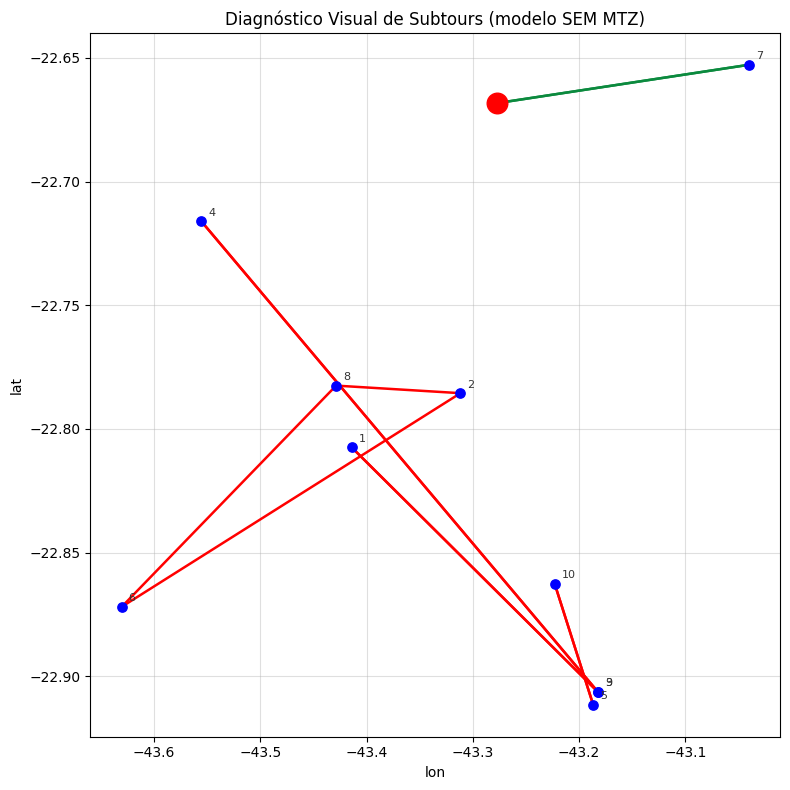

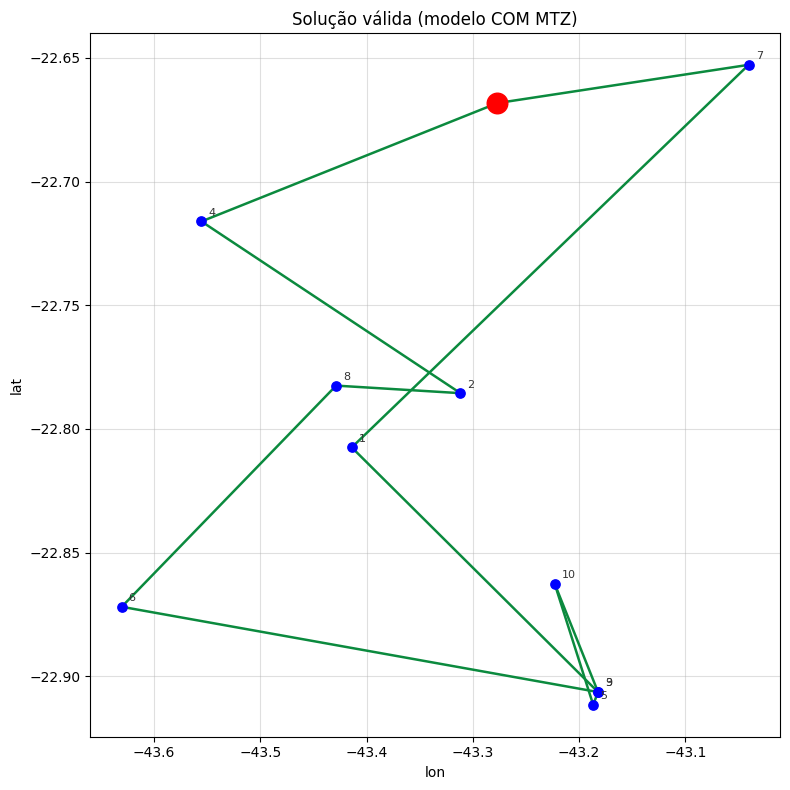

In [29]:
# ============================================================
# E1 — versão estática para o relatório
# ============================================================
diagnostico_estatico(rotas_sem, subtours_sem,
                     titulo="Diagnóstico Visual de Subtours (modelo SEM MTZ)",
                     arquivo=f"E1_subtours_{INSTANCIA}.png")

diagnostico_estatico(rotas_base, subtours_base,
                     titulo="Solução válida (modelo COM MTZ)",
                     arquivo=f"E1_com_mtz_{INSTANCIA}.png")

---
# **E2 — Análise do gap × time limit** 🟢

**Por que este experimento vem primeiro.** C1 resolve em segundos, mas C2, C3 e
C4 (25, 40 e 60 clientes) podem levar horas. Rodar E3–E6 sem saber quanto tempo
vale a pena esperar é desperdício de máquina. Aqui achamos o **joelho da curva**:
o ponto a partir do qual mais tempo de solver não compra qualidade.

**Como ler os dois limites:**
- *incumbente* (primal): melhor solução já encontrada — é o que você levaria para a operação;
- *bound* (dual): melhor garantia teórica — nenhuma solução pode custar menos que isso;
- o gap é a distância entre os dois. Ele fecha por **dois lados**: o incumbente
  cai e o bound sobe.

O experimento escolhe automaticamente a grade de tempos conforme o tamanho da
instância, e **para de rodar** assim que a otimalidade é provada — não faz sentido
gastar 24 h num problema já resolvido em 3 s.

In [30]:
# ============================================================
# E2 — GAP × TIME LIMIT
# ============================================================

# ---------------- CONFIGURAÇÃO ----------------
# C1 fecha em segundos: uma grade em horas daria uma reta horizontal inútil.
# C2-C4 são o caso real do enunciado.
TL_LEVE   = [1, 2, 5, 10, 30, 60, 300]                       # C1
TL_PESADO = [60, 300, 1800, 3600, 7200, 21600, 43200, 86400] # C2, C3, C4
#            1min 5min 30min  1h    2h     6h     12h    1dia

TIME_LIMITS = TL_LEVE if (n-1) <= 15 else TL_PESADO
PARAR_QUANDO_OTIMO = True     # não gaste 24h num problema já provado ótimo
# ----------------------------------------------

def rotulo_tempo(seg):
    if seg < 60:      return f"{seg:g}s"
    if seg < 3600:    return f"{seg/60:g}min"
    if seg < 86400:   return f"{seg/3600:g}h"
    return f"{seg/86400:g}d"

print(f"Instância {INSTANCIA} ({n-1} clientes) | solver: {SOLVER_PADRAO}")
print(f"Grade de time limits: {list(map(rotulo_tempo, TIME_LIMITS))}")
print(f"Pior caso de duração total: {rotulo_tempo(sum(TIME_LIMITS))}\n")

registros_e2 = []
for tl in TIME_LIMITS:
    mdl = build_model()
    r = resolver(mdl, SOLVER_PADRAO, time_limit=tl)
    r["rotulo"] = rotulo_tempo(tl)
    rr, ss = extrair_rotas(arcos_selecionados(mdl))
    r["subtours"] = len(ss)
    registros_e2.append(r)
    print(f"TL {r['rotulo']:>6} | {r['termination']:<18} | "
          f"tempo {r['tempo_s']:8.2f}s | custo R$ {r['custo']:9.2f} | "
          f"bound R$ {r['bound']:9.2f} | gap {r['gap_pct']:6.3f}%")
    if PARAR_QUANDO_OTIMO and r["otimo"]:
        print(f"\n→ Otimalidade PROVADA com TL = {r['rotulo']}. "
              f"Time limits maiores são desnecessários; interrompendo a grade.")
        break

df_e2 = pd.DataFrame(registros_e2)
df_e2.to_csv(f"E2_gap_timelimit_{INSTANCIA}.csv", index=False)
mostrar(df_e2[["rotulo","tempo_s","custo","bound","gap_pct","termination","otimo"]].round(3))

Instância C1 (10 clientes) | solver: gurobi_direct
Grade de time limits: ['1s', '2s', '5s', '10s', '30s', '1min', '5min']
Pior caso de duração total: 6.8min

TL     1s | optimal            | tempo     0.64s | custo R$    493.90 | bound R$    493.90 | gap  0.000%

→ Otimalidade PROVADA com TL = 1s. Time limits maiores são desnecessários; interrompendo a grade.


,rotulo,tempo_s,custo,bound,gap_pct,termination,otimo
0,1s,0.641,493.903,493.903,0.0,optimal,True


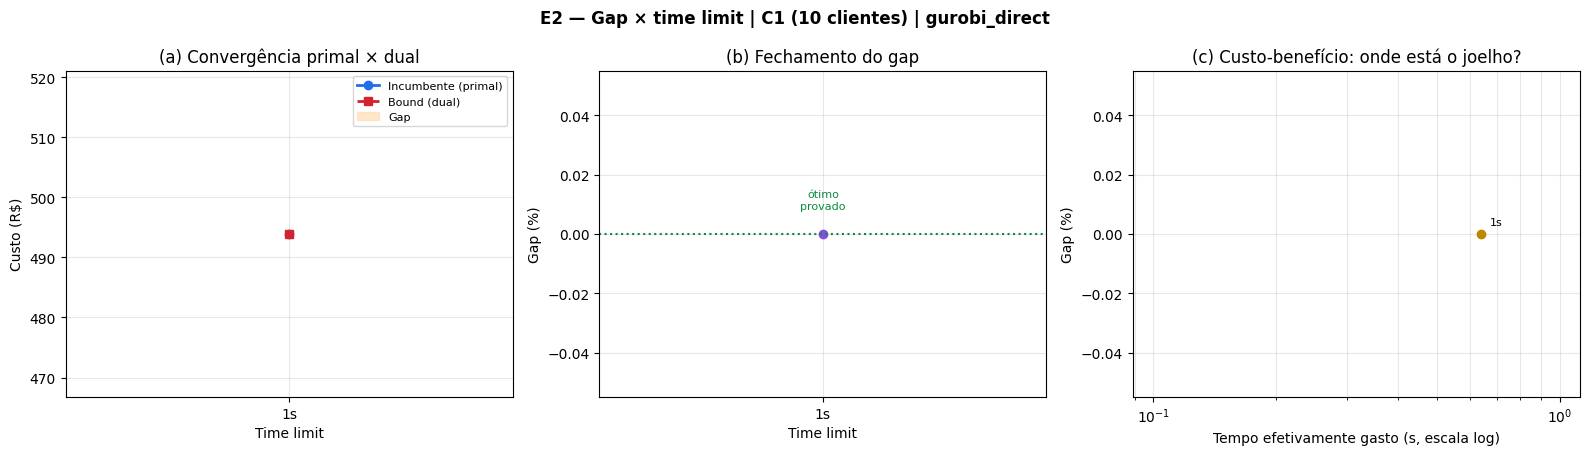

Menor gap obtido: 0.000% com TL = 1s
Primeiro time limit que PROVA otimalidade: 1s (gasto real: 0.64 s)
→ Recomendação para os demais experimentos em C1: TL = 1min é folgado.


In [31]:
# ============================================================
# E2 — GRÁFICOS
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
x = np.arange(len(df_e2))
rot = df_e2["rotulo"].tolist()

# (a) convergência: incumbente e bound se aproximando
ax = axes[0]
ax.plot(x, df_e2["custo"], "o-", color="#1f6feb", lw=2, label="Incumbente (primal)")
ax.plot(x, df_e2["bound"], "s--", color="#d1242f", lw=2, label="Bound (dual)")
ax.fill_between(x, df_e2["bound"], df_e2["custo"], color="#ffd8a8", alpha=.6, label="Gap")
ax.set_xticks(x); ax.set_xticklabels(rot)
ax.set_xlabel("Time limit"); ax.set_ylabel("Custo (R$)")
ax.set_title("(a) Convergência primal × dual")
ax.legend(fontsize=8); ax.grid(alpha=.3)

# (b) fechamento do gap
ax = axes[1]
ax.plot(x, df_e2["gap_pct"], "o-", color="#8250df", lw=2)
ax.axhline(0, color="#0b8a3e", ls=":", lw=1.5)
for xi, (g, o) in enumerate(zip(df_e2["gap_pct"], df_e2["otimo"])):
    if o:
        ax.annotate("ótimo\nprovado", (xi, g), textcoords="offset points",
                    xytext=(0, 18), ha="center", fontsize=8, color="#0b8a3e")
ax.set_xticks(x); ax.set_xticklabels(rot)
ax.set_xlabel("Time limit"); ax.set_ylabel("Gap (%)")
ax.set_title("(b) Fechamento do gap")
ax.grid(alpha=.3)

# (c) custo-benefício: tempo realmente gasto x qualidade
ax = axes[2]
ax.plot(df_e2["tempo_s"], df_e2["gap_pct"], "o-", color="#bf8700", lw=2)
for t, g, r in zip(df_e2["tempo_s"], df_e2["gap_pct"], rot):
    ax.annotate(r, (t, g), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Tempo efetivamente gasto (s, escala log)")
ax.set_ylabel("Gap (%)")
ax.set_title("(c) Custo-benefício: onde está o joelho?")
ax.grid(alpha=.3, which="both")

plt.suptitle(f"E2 — Gap × time limit | {INSTANCIA} ({n-1} clientes) | {SOLVER_PADRAO}",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"E2_gap_timelimit_{INSTANCIA}.png", dpi=150)
plt.show()

# ---- leitura automática do joelho ----
print(f"Menor gap obtido: {df_e2['gap_pct'].min():.3f}% "
      f"com TL = {df_e2.loc[df_e2['gap_pct'].idxmin(),'rotulo']}")
if df_e2["otimo"].any():
    prim = df_e2[df_e2["otimo"]].iloc[0]
    print(f"Primeiro time limit que PROVA otimalidade: {prim['rotulo']} "
          f"(gasto real: {prim['tempo_s']:.2f} s)")
    print(f"→ Recomendação para os demais experimentos em {INSTANCIA}: "
          f"TL = {rotulo_tempo(max(60, 3*prim['tempo_s']))} é folgado.")
else:
    print("Nenhum TL provou otimalidade — para esta instância, trabalhe com "
          "solução incumbente e reporte SEMPRE o gap junto do custo.")

---
# **E3 — Comparação entre solvers** 🔴

Três motores sobre **exatamente o mesmo modelo**: CBC (open-source clássico),
HiGHS (open-source moderno) e Gurobi (comercial).

Duas advertências que valem para o relatório:

1. **Solver melhor não muda o ótimo.** Se todos provarem otimalidade, todos
   devolvem o mesmo custo — o valor ótimo de um MILP é único. O que muda é o
   *tempo* para chegar lá e, sob time limit, a *qualidade* da incumbente.
2. **Solver melhor não anula o crescimento combinatório.** Um Gurobi 20× mais
   rápido compra você um punhado de clientes a mais, não uma ordem de grandeza.

O time limit comum é o que torna a comparação justa — sem ele, um solver lento
simplesmente demora mais e você não consegue comparar qualidade.

In [32]:
# ============================================================
# E3 — COMPARAÇÃO ENTRE SOLVERS
# ============================================================

# ---------------- CONFIGURAÇÃO ----------------
TL_COMPARACAO = 300 if (n-1) <= 15 else 1800   # segundos, igual para todos
CANDIDATOS = ["gurobi_direct", "appsi_highs", "cbc", "glpk"]
# ----------------------------------------------

lista = [sv for sv in CANDIDATOS if sv in DISPONIVEIS]
print(f"Solvers que serão comparados: {lista}")
print(f"Time limit comum: {TL_COMPARACAO} s\n")

registros_e3 = []
for sv in lista:
    mdl = build_model()
    try:
        r = resolver(mdl, sv, time_limit=TL_COMPARACAO)
    except Exception as e:
        print(f"{sv:>15} | FALHOU: {type(e).__name__}: {e}")
        continue
    rr, ss = extrair_rotas(arcos_selecionados(mdl))
    r["subtours"] = len(ss)
    r["rotas"] = len(rr)
    registros_e3.append(r)
    print(f"{sv:>15} | {r['termination']:<18} | tempo {r['tempo_s']:8.2f}s | "
          f"custo R$ {r['custo']:9.2f} | gap {r['gap_pct']:6.3f}%")

df_e3 = pd.DataFrame(registros_e3)
df_e3.to_csv(f"E3_solvers_{INSTANCIA}.csv", index=False)

if len(df_e3) > 1:
    ref = df_e3["tempo_s"].max()
    df_e3["speedup_vs_pior"] = ref / df_e3["tempo_s"]
mostrar(df_e3[["solver","tempo_s","custo","bound","gap_pct","termination"]].round(3))

if df_e3["otimo"].all() and len(df_e3) > 1:
    espalhamento = df_e3["custo"].max() - df_e3["custo"].min()
    print(f"\nTodos provaram otimalidade. Dispersão de custo entre solvers: "
          f"R$ {espalhamento:.6f}")
    print("→ Confirma o esperado: o ÓTIMO é único; o que difere é o tempo.")

Solvers que serão comparados: ['gurobi_direct', 'appsi_highs', 'cbc']
Time limit comum: 300 s

  gurobi_direct | optimal            | tempo     1.18s | custo R$    493.90 | gap  0.000%
    appsi_highs | optimal            | tempo    11.03s | custo R$    493.90 | gap  0.000%
            cbc | optimal            | tempo     4.97s | custo R$    493.90 | gap  0.000%


,solver,tempo_s,custo,bound,gap_pct,termination
0,gurobi_direct,1.179,493.903,493.903,0.0,optimal
1,appsi_highs,11.033,493.903,493.903,0.0,optimal
2,cbc,4.969,493.903,493.903,0.0,optimal



Todos provaram otimalidade. Dispersão de custo entre solvers: R$ 0.000000
→ Confirma o esperado: o ÓTIMO é único; o que difere é o tempo.


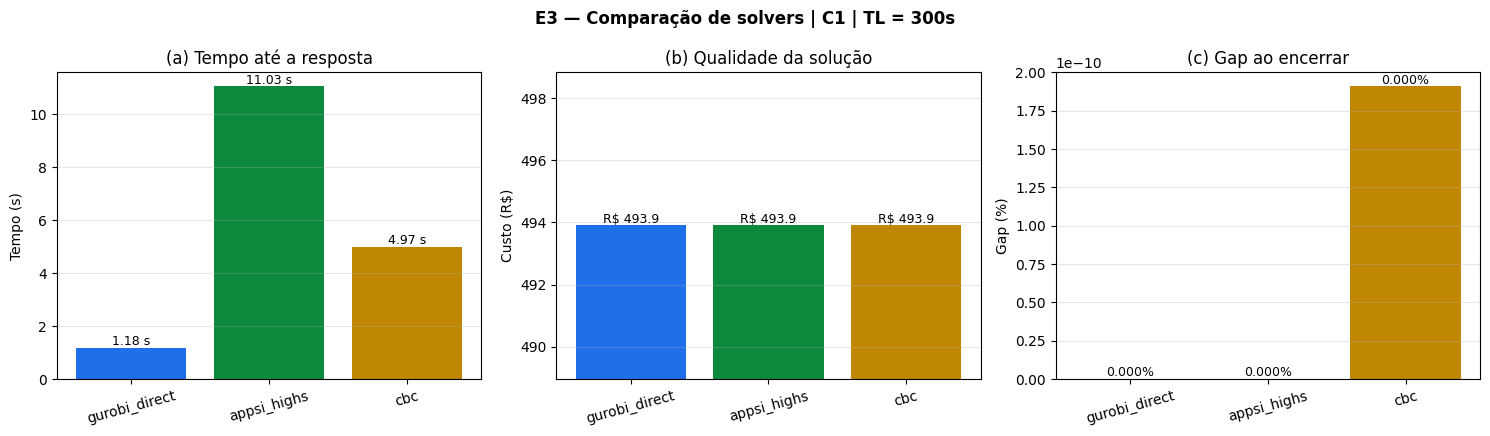

Mais rápido: gurobi_direct (1.18s)
Mais lento : appsi_highs (11.03s)
Speed-up: 9.4×

→ Use gurobi_direct nas instâncias maiores (C2-C4).


In [33]:
# ============================================================
# E3 — GRÁFICOS
# ============================================================
if len(df_e3) == 0:
    print("Nenhum solver rodou.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    cores = ["#1f6feb", "#0b8a3e", "#bf8700", "#8250df"]

    ax = axes[0]
    b = ax.bar(df_e3["solver"], df_e3["tempo_s"], color=cores[:len(df_e3)])
    ax.bar_label(b, fmt="%.2f s", fontsize=9)
    ax.set_ylabel("Tempo (s)"); ax.set_title("(a) Tempo até a resposta")
    ax.tick_params(axis="x", rotation=15); ax.grid(alpha=.3, axis="y")

    ax = axes[1]
    b = ax.bar(df_e3["solver"], df_e3["custo"], color=cores[:len(df_e3)])
    ax.bar_label(b, fmt="R$ %.1f", fontsize=9)
    lo, hi = df_e3["custo"].min(), df_e3["custo"].max()
    margem = max((hi - lo) * 0.5, hi * 0.01)
    ax.set_ylim(lo - margem, hi + margem)      # zoom: senão as barras parecem idênticas
    ax.set_ylabel("Custo (R$)"); ax.set_title("(b) Qualidade da solução")
    ax.tick_params(axis="x", rotation=15); ax.grid(alpha=.3, axis="y")

    ax = axes[2]
    b = ax.bar(df_e3["solver"], df_e3["gap_pct"], color=cores[:len(df_e3)])
    ax.bar_label(b, fmt="%.3f%%", fontsize=9)
    ax.set_ylabel("Gap (%)"); ax.set_title("(c) Gap ao encerrar")
    ax.tick_params(axis="x", rotation=15); ax.grid(alpha=.3, axis="y")

    plt.suptitle(f"E3 — Comparação de solvers | {INSTANCIA} | TL = {TL_COMPARACAO}s",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"E3_solvers_{INSTANCIA}.png", dpi=150)
    plt.show()

    if len(df_e3) > 1:
        mais_rapido = df_e3.loc[df_e3["tempo_s"].idxmin()]
        mais_lento  = df_e3.loc[df_e3["tempo_s"].idxmax()]
        print(f"Mais rápido: {mais_rapido['solver']} ({mais_rapido['tempo_s']:.2f}s)")
        print(f"Mais lento : {mais_lento['solver']} ({mais_lento['tempo_s']:.2f}s)")
        print(f"Speed-up: {mais_lento['tempo_s']/mais_rapido['tempo_s']:.1f}×")
        print(f"\n→ Use {mais_rapido['solver']} nas instâncias maiores (C2-C4).")

---
# **E4 — Velocidade média × tempo de serviço** 🟢

**Leia isto antes de interpretar os gráficos.** Nem `v_kmh`, nem `s`, nem `T`,
nem `H` entram no MIP. A função objetivo usa `C[i,j]` e `f[k]`; as restrições
usam `q`, `Q` e `x`. Tempo só aparece na validação pós-solução.

Logo: **variar velocidade ou tempo de serviço não muda a rota nem o custo.**
O que muda é se a rota ótima *cabe* na jornada de 8 h. Este é um experimento de
validação operacional, não de otimização — e o achado central para o relatório é
exatamente que o modelo **não reage**: ele mantém a mesma rota enquanto a
operação vira inviável.

Os dois parâmetros atacam o orçamento de 8 h por lados diferentes:

| | Velocidade | Tempo de serviço |
|---|---|---|
| afeta | deslocamento | atendimento |
| escala com | quilometragem da rota | nº de clientes da rota |
| pergunta operacional | "a malha viária aguenta?" | "quantas paradas cabem no dia?" |
| cenário real | trânsito, obra, chuva | fila no hospital, conferência de nota |

In [34]:
# ============================================================
# E4 — VELOCIDADE × TEMPO DE SERVIÇO
# ============================================================
# A rota é a da solução ótima (baseline) e NÃO muda. Recalculamos apenas os
# tempos, exatamente como a célula (20) faria com outros parâmetros.

# ---------------- CONFIGURAÇÃO ----------------
VELOCIDADES = [15, 20, 25, 30, 35, 40, 50, 60, 70, 80]     # km/h
SERVICOS_MIN = [5, 10, 15, 20, 25, 30, 40, 45, 60]         # min/cliente
# ----------------------------------------------

def tempos_da_rota(rota, v, s_min):
    '''Tempo da rota sob (v km/h, s_min min/cliente). Rota fixa.'''
    km = km_rota(rota)
    nc = len([x for x in rota if x != 0])
    t_mov = km / v
    t_serv = nc * (s_min / 60.0)
    return km, nc, t_mov, t_serv, t_mov + t_serv

linhas = []
for k, rota in rotas_base:
    for v in VELOCIDADES:
        for sm in SERVICOS_MIN:
            km, nc, tm, ts, tt = tempos_da_rota(rota, v, sm)
            linhas.append({
                "tipo": k, "km": km, "n_clientes": nc,
                "v_kmh": v, "s_min": sm,
                "t_desloc_h": tm, "t_servico_h": ts, "t_total_h": tt,
                "pct_desloc": 100*tm/tt if tt > 0 else 0,
                "folga_h": H - tt,
                "viavel": tt <= H + 1e-9,
            })

df_e4 = pd.DataFrame(linhas)
df_e4.to_csv(f"E4_velocidade_servico_{INSTANCIA}.csv", index=False)

# --- métricas no ponto de referência (40 km/h, 15 min) ---
ref = df_e4[(df_e4.v_kmh == v_BASE) & (df_e4.s_min == round(s_BASE[1]*60))]
print("=== PONTO DE REFERÊNCIA (v = 40 km/h, s = 15 min) ===")
mostrar(ref[["tipo","km","n_clientes","t_desloc_h","t_servico_h",
             "t_total_h","pct_desloc","folga_h","viavel"]].round(2))

# --- fronteiras de viabilidade por rota ---
print("\n=== FRONTEIRAS DE VIABILIDADE (H = 8 h) ===")
for k, rota in rotas_base:
    km = km_rota(rota)
    nc = len([x for x in rota if x != 0])
    t_serv_ref = nc * (s_BASE[1])
    t_mov_ref = km / v_BASE
    v_min = km / (H - t_serv_ref) if (H - t_serv_ref) > 0 else float("inf")
    s_max = 60*(H - t_mov_ref)/nc if nc else float("inf")
    print(f"[{k}] {nc} clientes, {km:.1f} km:")
    print(f"     velocidade mínima  (mantendo s=15 min): {v_min:5.1f} km/h")
    print(f"     serviço máximo/cliente (mantendo v=40): {s_max:5.1f} min")

=== PONTO DE REFERÊNCIA (v = 40 km/h, s = 15 min) ===


,tipo,km,n_clientes,t_desloc_h,t_servico_h,t_total_h,pct_desloc,folga_h,viavel
47,FIO,162.6,10,4.07,2.5,6.57,61.92,1.43,True



=== FRONTEIRAS DE VIABILIDADE (H = 8 h) ===
[FIO] 10 clientes, 162.6 km:
     velocidade mínima  (mantendo s=15 min):  29.6 km/h
     serviço máximo/cliente (mantendo v=40):  23.6 min


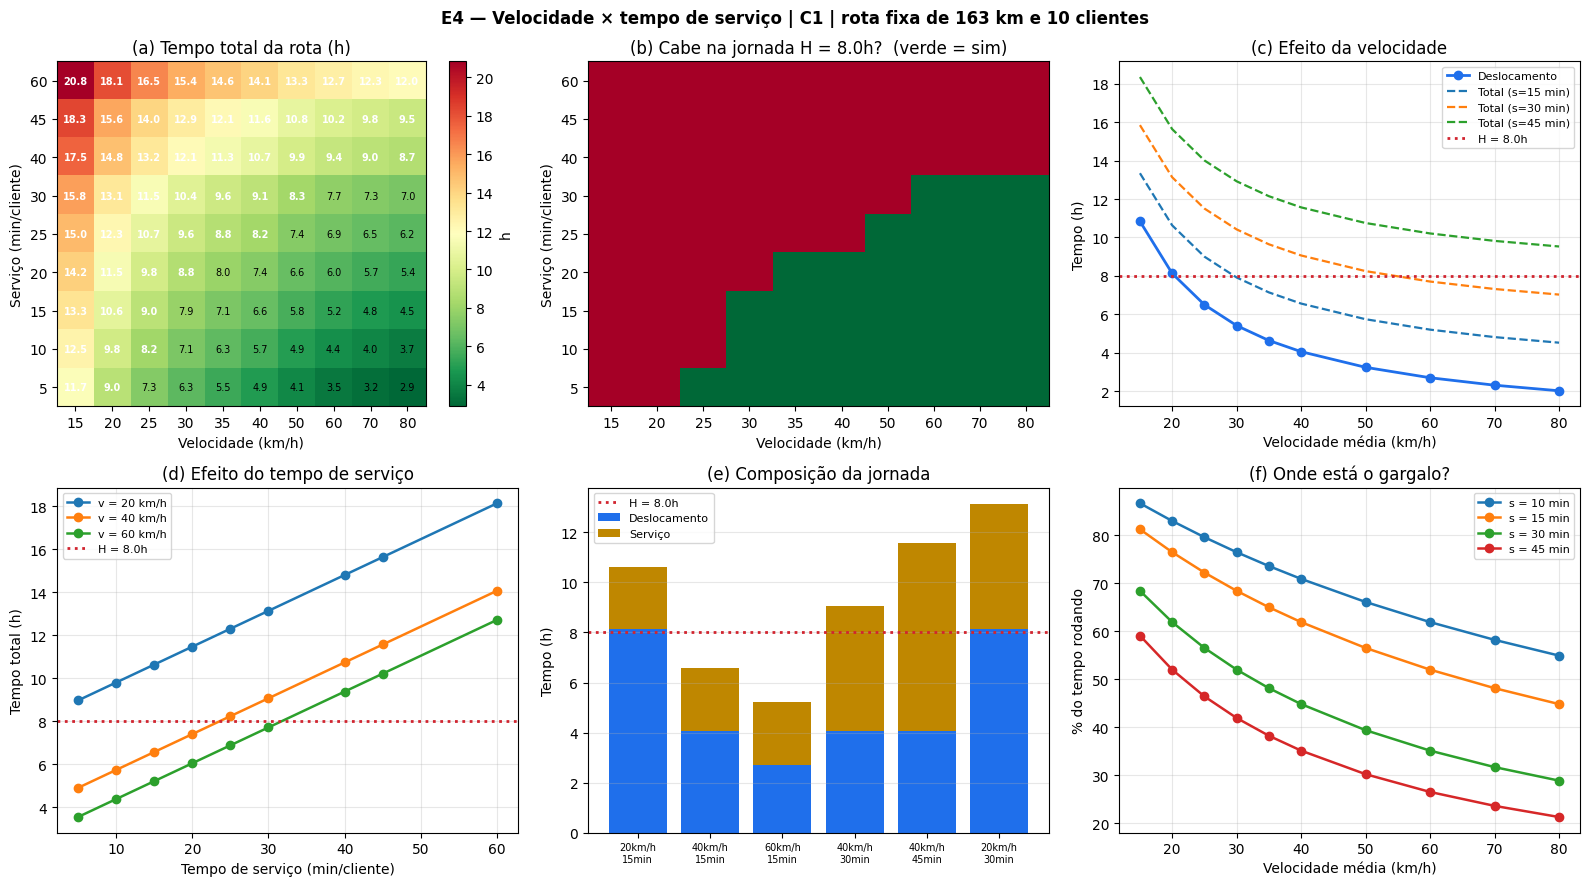

Nos painéis (c) e (d) a curva NUNCA muda de forma: a rota é sempre a mesma.
O modelo é cego a esses parâmetros — só a validação enxerga a violação.


In [35]:
# ============================================================
# E4 — GRÁFICOS
# ============================================================
rota_ref = rotas_base[0][1]
km_ref = km_rota(rota_ref)
nc_ref = len([x for x in rota_ref if x != 0])
sub = df_e4[df_e4.km == km_ref]

fig = plt.figure(figsize=(16, 9))

# (a) heatmap tempo total
ax = fig.add_subplot(2, 3, 1)
piv = sub.pivot_table(index="s_min", columns="v_kmh", values="t_total_h")
im = ax.imshow(piv.values, cmap="RdYlGn_r", aspect="auto", origin="lower")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("Velocidade (km/h)"); ax.set_ylabel("Serviço (min/cliente)")
ax.set_title("(a) Tempo total da rota (h)")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        val = piv.values[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7,
                color="white" if val > H else "black",
                fontweight="bold" if val > H else "normal")
plt.colorbar(im, ax=ax, label="h")

# (b) fronteira de viabilidade
ax = fig.add_subplot(2, 3, 2)
pv = sub.pivot_table(index="s_min", columns="v_kmh", values="viavel")
ax.imshow(pv.values.astype(float), cmap="RdYlGn", aspect="auto",
          origin="lower", vmin=0, vmax=1)
ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(pv.columns)
ax.set_yticks(range(len(pv.index)));   ax.set_yticklabels(pv.index)
ax.set_xlabel("Velocidade (km/h)"); ax.set_ylabel("Serviço (min/cliente)")
ax.set_title(f"(b) Cabe na jornada H = {H}h?  (verde = sim)")

# (c) curva do deslocamento vs velocidade
ax = fig.add_subplot(2, 3, 3)
vs = np.array(VELOCIDADES, dtype=float)
ax.plot(vs, km_ref/vs, "o-", color="#1f6feb", lw=2, label="Deslocamento")
for sm in [15, 30, 45]:
    ax.plot(vs, km_ref/vs + nc_ref*sm/60, "--", lw=1.6,
            label=f"Total (s={sm} min)")
ax.axhline(H, color="#d1242f", ls=":", lw=2, label=f"H = {H}h")
ax.set_xlabel("Velocidade média (km/h)"); ax.set_ylabel("Tempo (h)")
ax.set_title("(c) Efeito da velocidade")
ax.legend(fontsize=8); ax.grid(alpha=.3)

# (d) curva do serviço
ax = fig.add_subplot(2, 3, 4)
ss = np.array(SERVICOS_MIN, dtype=float)
for v in [20, 40, 60]:
    ax.plot(ss, km_ref/v + nc_ref*ss/60, "o-", lw=1.8, label=f"v = {v} km/h")
ax.axhline(H, color="#d1242f", ls=":", lw=2, label=f"H = {H}h")
ax.set_xlabel("Tempo de serviço (min/cliente)"); ax.set_ylabel("Tempo total (h)")
ax.set_title("(d) Efeito do tempo de serviço")
ax.legend(fontsize=8); ax.grid(alpha=.3)

# (e) composição do tempo
ax = fig.add_subplot(2, 3, 5)
cen = [(20,15),(40,15),(60,15),(40,30),(40,45),(20,30)]
rot = [f"{v}km/h\n{sm}min" for v, sm in cen]
mov = [km_ref/v for v, sm in cen]
ser = [nc_ref*sm/60 for v, sm in cen]
ax.bar(rot, mov, color="#1f6feb", label="Deslocamento")
ax.bar(rot, ser, bottom=mov, color="#bf8700", label="Serviço")
ax.axhline(H, color="#d1242f", ls=":", lw=2, label=f"H = {H}h")
ax.set_ylabel("Tempo (h)"); ax.set_title("(e) Composição da jornada")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelsize=7); ax.grid(alpha=.3, axis="y")

# (f) % do tempo em deslocamento
ax = fig.add_subplot(2, 3, 6)
for sm in [10, 15, 30, 45]:
    pct = 100*(km_ref/vs)/(km_ref/vs + nc_ref*sm/60)
    ax.plot(vs, pct, "o-", lw=1.8, label=f"s = {sm} min")
ax.set_xlabel("Velocidade média (km/h)"); ax.set_ylabel("% do tempo rodando")
ax.set_title("(f) Onde está o gargalo?")
ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.suptitle(f"E4 — Velocidade × tempo de serviço | {INSTANCIA} | "
             f"rota fixa de {km_ref:.0f} km e {nc_ref} clientes", fontweight="bold")
plt.tight_layout()
plt.savefig(f"E4_velocidade_servico_{INSTANCIA}.png", dpi=150)
plt.show()

print(f"Nos painéis (c) e (d) a curva NUNCA muda de forma: a rota é sempre a mesma.")
print(f"O modelo é cego a esses parâmetros — só a validação enxerga a violação.")

---
# **E5 — Variação do custo fixo do VUC** 🔴

> *"Em qual ponto o modelo deixa de usar o VUC?"*

Atenção à leitura da instância **C1**: a demanda total é de ~339 kg, metade de um
único Fiorino (650 kg). Com o custo fixo de referência (R$ 550 contra R$ 250), o
modelo **nunca** liga o VUC — a pergunta do enunciado se inverte: *a partir de
qual custo ele PASSA a usar o VUC?*

Este é o experimento em que o problema do Pyomo aparece com toda a força.
Alterar `f["VUC"]` e chamar `solver.solve()` de novo devolve o mesmo custo,
porque a expressão do objetivo já foi construída com o número antigo.
Por isso cada ponto do gráfico é um `build_model()` novo.

A varredura grossa desenha a curva; a busca binária localiza o ponto de troca
com precisão de centavos, sem gastar dezenas de solves.

In [36]:
# ============================================================
# E5 — CUSTO FIXO DO VUC
# ============================================================

# ---------------- CONFIGURAÇÃO ----------------
F_VUC_GRADE = list(range(0, 901, 50))    # varredura grossa (R$)
TL_E5 = None if (n-1) <= 15 else 300     # em C2-C4, limite por ponto
REFINAR_BISSECCAO = True
# ----------------------------------------------

def usa_vuc(f_vuc, tl=TL_E5):
    mdl = build_model(f={"VUC": float(f_vuc)})
    r = resolver(mdl, SOLVER_PADRAO, time_limit=tl)
    y = {k: value(mdl.y[k]) for k in mdl.K}
    return r, y, mdl

print(f"Varredura: {len(F_VUC_GRADE)} pontos, um build_model() por ponto.\n")

registros_e5 = []
for fv in F_VUC_GRADE:
    r, y, mdl = usa_vuc(fv)
    km_tot = sum(D[i,j]*value(mdl.x[i,j,k]) for (i,j,k) in mdl.A)
    registros_e5.append({
        "f_vuc": fv,
        "custo": r["custo"],
        "y_VUC": round(y.get("VUC", 0)),
        "y_FIO": round(y.get("FIO", 0)),
        "km": km_tot,
        "custo_variavel": r["custo"] - (fv*round(y.get("VUC",0))
                                        + f_BASE["FIO"]*round(y.get("FIO",0))),
        "tempo_s": r["tempo_s"],
        "frota": ("VUC" if round(y.get("VUC",0)) else "") +
                 ("+" if round(y.get("VUC",0)) and round(y.get("FIO",0)) else "") +
                 ("FIO" if round(y.get("FIO",0)) else ""),
    })
    print(f"f[VUC] = R$ {fv:4d} | custo R$ {r['custo']:8.2f} | "
          f"frota: {registros_e5[-1]['frota']:<8} | {km_tot:6.1f} km")

df_e5 = pd.DataFrame(registros_e5)
df_e5.to_csv(f"E5_custo_fixo_vuc_{INSTANCIA}.csv", index=False)

# ---- ponto de troca por bisseção ----
ponto_troca = None
if REFINAR_BISSECCAO:
    usados = df_e5[df_e5.y_VUC == 1]["f_vuc"]
    naousados = df_e5[df_e5.y_VUC == 0]["f_vuc"]
    if len(usados) and len(naousados):
        lo, hi = usados.max(), naousados.min()
        if lo < hi:
            print(f"\nRefinando o ponto de troca entre R$ {lo} e R$ {hi}...")
            for _ in range(12):
                mid = (lo + hi) / 2
                _, y, _ = usa_vuc(mid)
                if round(y.get("VUC", 0)) == 1:
                    lo = mid
                else:
                    hi = mid
            ponto_troca = (lo + hi) / 2
            print(f"→ Ponto de troca: f[VUC] ≈ R$ {ponto_troca:.2f}")
    else:
        print("\nO VUC foi usado (ou ignorado) em toda a faixa varrida — "
              "amplie F_VUC_GRADE.")

mostrar(df_e5.round(2))

Varredura: 19 pontos, um build_model() por ponto.

f[VUC] = R$    0 | custo R$   243.90 | frota: VUC      |  162.6 km
f[VUC] = R$   50 | custo R$   293.90 | frota: VUC      |  162.6 km
f[VUC] = R$  100 | custo R$   343.90 | frota: VUC      |  162.6 km
f[VUC] = R$  150 | custo R$   393.90 | frota: VUC      |  162.6 km
f[VUC] = R$  200 | custo R$   443.90 | frota: VUC      |  162.6 km
f[VUC] = R$  250 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  300 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  350 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  400 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  450 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  500 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  550 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  600 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$  650 | custo R$   493.90 | frota: FIO      |  162.6 km
f[VUC] = R$

,f_vuc,custo,y_VUC,y_FIO,km,custo_variavel,tempo_s,frota
0,0,243.9,1,0,162.6,243.9,0.59,VUC
1,50,293.9,1,0,162.6,243.9,0.23,VUC
2,100,343.9,1,0,162.6,243.9,0.21,VUC
3,150,393.9,1,0,162.6,243.9,0.21,VUC
4,200,443.9,1,0,162.6,243.9,0.85,VUC
5,250,493.9,0,1,162.6,243.9,0.30,FIO
6,300,493.9,0,1,162.6,243.9,0.23,FIO
7,350,493.9,0,1,162.6,243.9,0.28,FIO
8,400,493.9,0,1,162.6,243.9,0.22,FIO
9,450,493.9,0,1,162.6,243.9,0.24,FIO


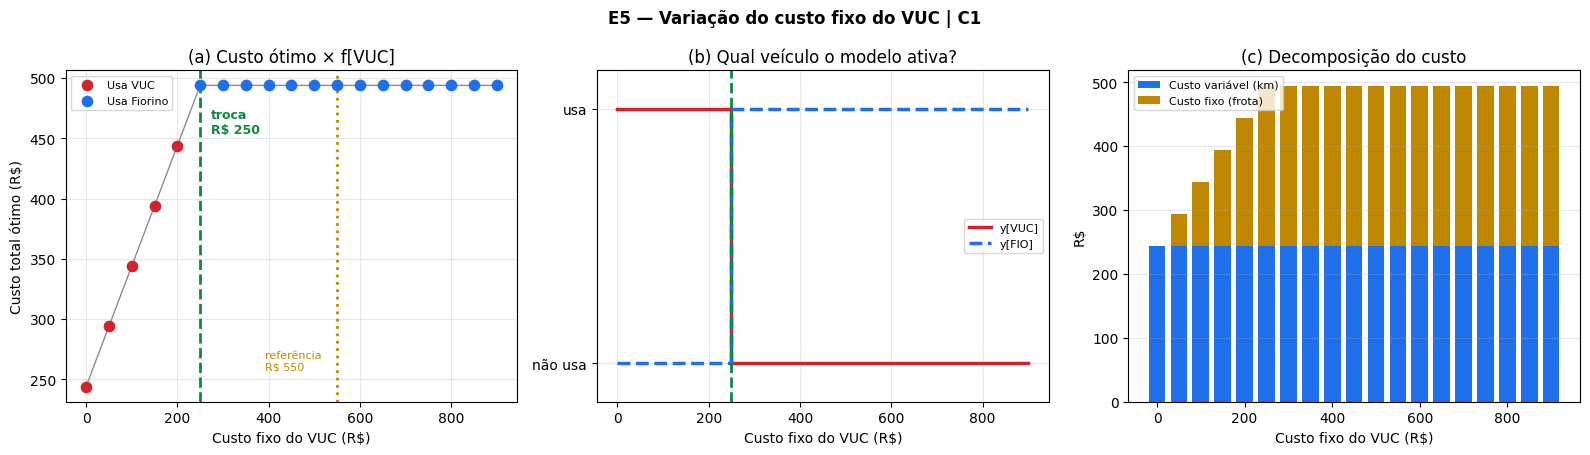

Leitura do painel (c): o custo VARIÁVEL é praticamente constante em toda a
faixa. Com no máximo uma rota por tipo e demanda baixa, o roteamento colapsa
num TSP único — a decisão de frota vira 'qual é o veículo mais barato que
comporta a carga'. Em C2-C4, com demanda maior, isso deixa de valer.


In [37]:
# ============================================================
# E5 — GRÁFICOS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) custo total vs f[VUC], colorido pela frota escolhida
ax = axes[0]
usa = df_e5.y_VUC == 1
ax.plot(df_e5["f_vuc"], df_e5["custo"], "-", color="#8c8c8c", lw=1, zorder=1)
ax.scatter(df_e5.loc[usa, "f_vuc"], df_e5.loc[usa, "custo"],
           color="#d1242f", s=55, zorder=3, label="Usa VUC")
ax.scatter(df_e5.loc[~usa, "f_vuc"], df_e5.loc[~usa, "custo"],
           color="#1f6feb", s=55, zorder=3, label="Usa Fiorino")
if ponto_troca:
    ax.axvline(ponto_troca, color="#0b8a3e", ls="--", lw=2)
    ax.annotate(f"troca\nR$ {ponto_troca:.0f}", (ponto_troca, df_e5["custo"].mean()),
                textcoords="offset points", xytext=(8, 0), fontsize=9,
                color="#0b8a3e", fontweight="bold")
ax.axvline(f_BASE["VUC"], color="#bf8700", ls=":", lw=2)
ax.annotate("referência\nR$ 550", (f_BASE["VUC"], df_e5["custo"].min()),
            textcoords="offset points", xytext=(-52, 12), fontsize=8, color="#bf8700")
ax.set_xlabel("Custo fixo do VUC (R$)"); ax.set_ylabel("Custo total ótimo (R$)")
ax.set_title("(a) Custo ótimo × f[VUC]")
ax.legend(fontsize=8); ax.grid(alpha=.3)

# (b) decisão binária: a "chave" liga/desliga
ax = axes[1]
ax.step(df_e5["f_vuc"], df_e5["y_VUC"], where="post", lw=2.5, color="#d1242f",
        label="y[VUC]")
ax.step(df_e5["f_vuc"], df_e5["y_FIO"], where="post", lw=2.5, color="#1f6feb",
        ls="--", label="y[FIO]")
if ponto_troca:
    ax.axvline(ponto_troca, color="#0b8a3e", ls="--", lw=2)
ax.set_ylim(-.15, 1.15); ax.set_yticks([0, 1])
ax.set_yticklabels(["não usa", "usa"])
ax.set_xlabel("Custo fixo do VUC (R$)")
ax.set_title("(b) Qual veículo o modelo ativa?")
ax.legend(fontsize=8); ax.grid(alpha=.3)

# (c) decomposição fixo x variável
ax = axes[2]
fixo = df_e5["custo"] - df_e5["custo_variavel"]
ax.bar(df_e5["f_vuc"], df_e5["custo_variavel"], width=38,
       color="#1f6feb", label="Custo variável (km)")
ax.bar(df_e5["f_vuc"], fixo, bottom=df_e5["custo_variavel"], width=38,
       color="#bf8700", label="Custo fixo (frota)")
ax.set_xlabel("Custo fixo do VUC (R$)"); ax.set_ylabel("R$")
ax.set_title("(c) Decomposição do custo")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

plt.suptitle(f"E5 — Variação do custo fixo do VUC | {INSTANCIA}", fontweight="bold")
plt.tight_layout()
plt.savefig(f"E5_custo_fixo_vuc_{INSTANCIA}.png", dpi=150)
plt.show()

print("Leitura do painel (c): o custo VARIÁVEL é praticamente constante em toda a")
print("faixa. Com no máximo uma rota por tipo e demanda baixa, o roteamento colapsa")
print("num TSP único — a decisão de frota vira 'qual é o veículo mais barato que")
print("comporta a carga'. Em C2-C4, com demanda maior, isso deixa de valer.")

---
# **E6 — Qualidade da solução obtida** 🟢

E2 perguntou *"quanto tempo dou ao solver?"*. E6 pergunta o inverso:
*"que qualidade eu aceito, e quanto tempo isso me economiza?"*

Em vez de limitar o tempo, limitamos a **tolerância de gap** (`MIPGap`).
Dizer ao solver "pare quando estiver a 5% do ótimo" costuma cortar a maior parte
do tempo, porque o grosso do esforço de um B&B não está em *achar* a boa solução
— está em **provar** que não existe melhor.

A pergunta de engenharia por trás: numa operação que fecha a roteirização às
18h para o dia seguinte, você espera 6 horas por 1% de custo?

**Armadilha de leitura.** Com `MIPGap = 20%`, o solver encerra reportando
`termination = optimal` — mas isso significa apenas *"ótimo dentro da tolerância
que você pediu"*, não *"ótimo provado"*. É por isso que o status do solver nunca
deve ser reportado sozinho: **sempre junto do gap**.

In [38]:
# ============================================================
# E6 — QUALIDADE (TOLERÂNCIA DE GAP) × ESFORÇO
# ============================================================

# ---------------- CONFIGURAÇÃO ----------------
GAPS = [0.20, 0.10, 0.05, 0.02, 0.01, 0.005, 0.0]   # fração (0.05 = 5%)
TL_E6 = 300 if (n-1) <= 15 else 3600
# ----------------------------------------------

print(f"Time limit de segurança por rodada: {TL_E6}s\n")

registros_e6 = []
for g in GAPS:
    mdl = build_model()
    r = resolver(mdl, SOLVER_PADRAO, time_limit=TL_E6, mip_gap=g)
    rr, ss = extrair_rotas(arcos_selecionados(mdl))
    r["gap_pedido_pct"] = 100*g
    r["subtours"] = len(ss)
    registros_e6.append(r)
    print(f"MIPGap pedido {100*g:5.1f}% | tempo {r['tempo_s']:7.2f}s | "
          f"custo R$ {r['custo']:9.2f} | gap real {r['gap_pct']:6.3f}% | "
          f"{r['termination']}")

df_e6 = pd.DataFrame(registros_e6)
custo_otimo = df_e6["custo"].min()
df_e6["perda_pct"] = 100*(df_e6["custo"] - custo_otimo)/custo_otimo
tempo_max = df_e6["tempo_s"].max()
df_e6["economia_tempo_pct"] = 100*(1 - df_e6["tempo_s"]/tempo_max)
df_e6.to_csv(f"E6_qualidade_{INSTANCIA}.csv", index=False)

mostrar(df_e6[["gap_pedido_pct","tempo_s","custo","gap_pct",
               "perda_pct","economia_tempo_pct","termination"]].round(3))

Time limit de segurança por rodada: 300s

MIPGap pedido  20.0% | tempo    0.13s | custo R$    538.98 | gap real 16.530% | optimal
MIPGap pedido  10.0% | tempo    0.20s | custo R$    495.86 | gap real  8.086% | optimal
MIPGap pedido   5.0% | tempo    0.21s | custo R$    493.90 | gap real  4.748% | optimal
MIPGap pedido   2.0% | tempo    0.25s | custo R$    493.90 | gap real  1.991% | optimal
MIPGap pedido   1.0% | tempo    0.24s | custo R$    493.90 | gap real  0.943% | optimal
MIPGap pedido   0.5% | tempo    0.26s | custo R$    493.90 | gap real  0.497% | optimal
MIPGap pedido   0.0% | tempo    0.25s | custo R$    493.90 | gap real  0.000% | optimal


,gap_pedido_pct,tempo_s,custo,gap_pct,perda_pct,economia_tempo_pct,termination
0,20.0,0.128,538.976,16.530,9.126,51.186,optimal
1,10.0,0.196,495.865,8.086,0.397,25.649,optimal
2,5.0,0.206,493.903,4.748,0.000,21.774,optimal
3,2.0,0.253,493.903,1.991,0.000,3.593,optimal
4,1.0,0.242,493.903,0.943,0.000,7.888,optimal
5,0.5,0.263,493.903,0.497,0.000,0.000,optimal
6,0.0,0.252,493.903,0.000,0.000,4.128,optimal


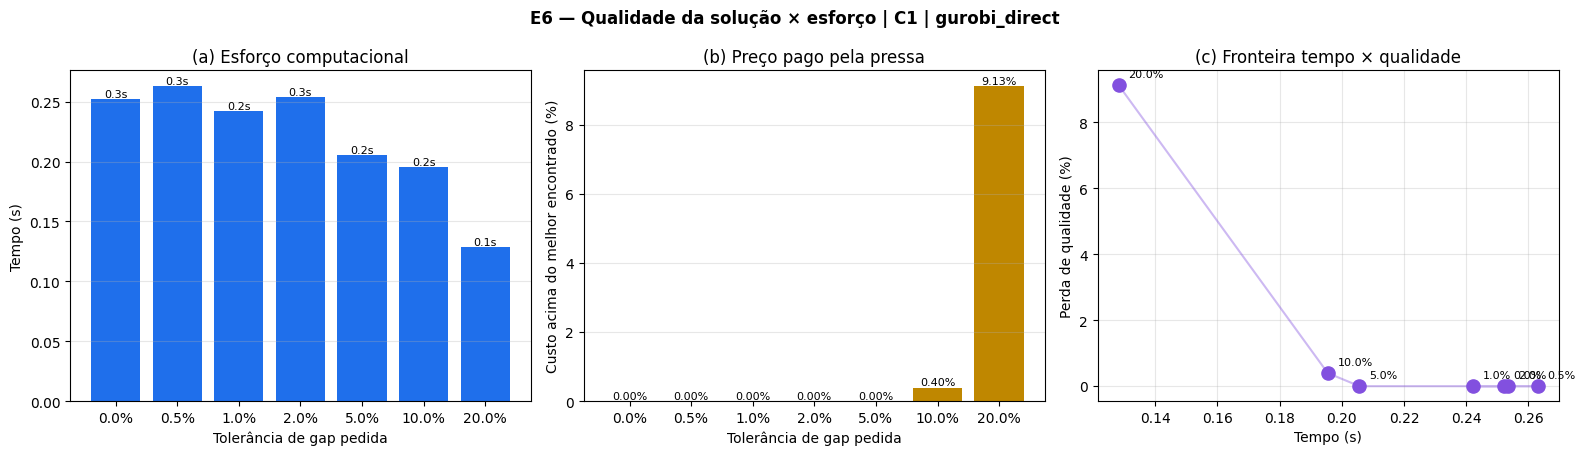

Melhor custo-benefício (perda ≤ 1%): MIPGap = 10.0% → 0.20s, custo R$ 495.86 (0.40% acima do melhor).

Repare na coluna 'termination': o solver diz 'optimal' mesmo quando parou
a 20% do ótimo. 'Optimal' = dentro da tolerância PEDIDA. Nunca reporte o
status sem o gap ao lado.

Em C1 a diferença é pequena porque o problema é fácil. Repita em C3/C4:
é lá que uma tolerância de 2-5% costuma transformar horas em minutos.


In [39]:
# ============================================================
# E6 — GRÁFICOS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
d = df_e6.sort_values("gap_pedido_pct")

ax = axes[0]
b = ax.bar(d["gap_pedido_pct"].astype(str) + "%", d["tempo_s"], color="#1f6feb")
ax.bar_label(b, fmt="%.1fs", fontsize=8)
ax.set_xlabel("Tolerância de gap pedida"); ax.set_ylabel("Tempo (s)")
ax.set_title("(a) Esforço computacional")
ax.grid(alpha=.3, axis="y")

ax = axes[1]
b = ax.bar(d["gap_pedido_pct"].astype(str) + "%", d["perda_pct"], color="#bf8700")
ax.bar_label(b, fmt="%.2f%%", fontsize=8)
ax.set_xlabel("Tolerância de gap pedida")
ax.set_ylabel("Custo acima do melhor encontrado (%)")
ax.set_title("(b) Preço pago pela pressa")
ax.grid(alpha=.3, axis="y")

ax = axes[2]
ax.scatter(d["tempo_s"], d["perda_pct"], s=90, color="#8250df", zorder=3)
for _, row in d.iterrows():
    ax.annotate(f"{row['gap_pedido_pct']:.1f}%", (row["tempo_s"], row["perda_pct"]),
                textcoords="offset points", xytext=(7, 6), fontsize=8)
ax.plot(d["tempo_s"], d["perda_pct"], "-", color="#8250df", alpha=.4, zorder=2)
ax.set_xlabel("Tempo (s)"); ax.set_ylabel("Perda de qualidade (%)")
ax.set_title("(c) Fronteira tempo × qualidade")
ax.grid(alpha=.3)

plt.suptitle(f"E6 — Qualidade da solução × esforço | {INSTANCIA} | {SOLVER_PADRAO}",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"E6_qualidade_{INSTANCIA}.png", dpi=150)
plt.show()

barato = d[d["perda_pct"] <= 1.0]
if len(barato):
    esc = barato.loc[barato["tempo_s"].idxmin()]
    print(f"Melhor custo-benefício (perda ≤ 1%): MIPGap = {esc['gap_pedido_pct']:.1f}% "
          f"→ {esc['tempo_s']:.2f}s, custo R$ {esc['custo']:.2f} "
          f"({esc['perda_pct']:.2f}% acima do melhor).")
print("\nRepare na coluna 'termination': o solver diz 'optimal' mesmo quando parou")
print("a 20% do ótimo. 'Optimal' = dentro da tolerância PEDIDA. Nunca reporte o")
print("status sem o gap ao lado.")
print("\nEm C1 a diferença é pequena porque o problema é fácil. Repita em C3/C4:")
print("é lá que uma tolerância de 2-5% costuma transformar horas em minutos.")

---
# **Consolidação — o que levar para o relatório**

In [40]:
# ============================================================
# CONSOLIDAÇÃO E EXPORTAÇÃO
# ============================================================
# Todos os experimentos já salvaram seu CSV e seu PNG. Aqui juntamos tudo
# num resumo único, pronto para a comparação com as outras equipes da turma
# (experimento obrigatório do slide 20).

resumo = {
    "instancia": INSTANCIA,
    "clientes": n-1,
    "demanda_total_kg": float(q[1:].sum()),
    "binarias": len(modelo_base.A),
    "restricoes": len(list(modelo_base.component_data_objects(Constraint))),
    "solver_padrao": SOLVER_PADRAO,
    "custo_otimo": float(res_base["custo"]),
    "gap_pct": float(res_base["gap_pct"]),
    "tempo_s": float(res_base["tempo_s"]),
    "rotas": len(rotas_base),
    "subtours": len(subtours_base),
    "km_total": float(sum(km_rota(r) for _, r in rotas_base)),
    "frota_ativada": [k for k in modelo_base.K if value(modelo_base.y[k]) > 0.5],
    "E1_custo_sem_mtz": float(res_sem_mtz["custo"]),
    "E1_subtours_sem_mtz": len(subtours_sem),
    "E5_ponto_troca_vuc": ponto_troca,
}

print("="*68)
print(f"RESUMO — {INSTANCIA}")
print("="*68)
for k, v in resumo.items():
    print(f"{k:24s}: {v}")

with open(f"resumo_{INSTANCIA}.json", "w") as fh:
    json.dump(resumo, fh, indent=2, ensure_ascii=False, default=str)

df_base.to_csv(f"rotas_{INSTANCIA}.csv", index=False)

print("\nArquivos gerados nesta sessão:")
for arq in sorted(os.listdir()):
    if arq.startswith(("E1_","E2_","E3_","E4_","E5_","E6_","resumo_","rotas_")):
        print("  ", arq)

# No Colab, para baixar tudo:
# from google.colab import files
# for arq in os.listdir():
#     if arq.startswith(("E1_","E2_","E3_","E4_","E5_","E6_","resumo_","rotas_")):
#         files.download(arq)

RESUMO — C1
instancia               : C1
clientes                : 10
demanda_total_kg        : 339.272
binarias                : 220
restricoes              : 139
solver_padrao           : gurobi_direct
custo_otimo             : 493.9027674309417
gap_pct                 : 0.0
tempo_s                 : 0.5350239276885986
rotas                   : 1
subtours                : 0
km_total                : 162.60184495396112
frota_ativada           : ['FIO']
E1_custo_sem_mtz        : 427.9377534799166
E1_subtours_sem_mtz     : 4
E5_ponto_troca_vuc      : 249.993896484375

Arquivos gerados nesta sessão:
   E1_com_mtz_C1.png
   E1_subtours_C1.png
   E2_gap_timelimit_C1.csv
   E2_gap_timelimit_C1.png
   E3_solvers_C1.csv
   E3_solvers_C1.png
   E4_velocidade_servico_C1.csv
   E4_velocidade_servico_C1.png
   E5_custo_fixo_vuc_C1.csv
   E5_custo_fixo_vuc_C1.png
   E6_qualidade_C1.csv
   E6_qualidade_C1.png
   resumo_C1.json
   rotas_C1.csv


---
## Como rodar em C2, C3 e C4

O notebook foi escrito para não precisar de edição estrutural entre instâncias.
O roteiro é:

1. **Célula (2)**: troque `INSTANCIA = "C1"` por C1, C2, C3 ou C4.
   O notebook localizará automaticamente os arquivos na pasta local correspondente.
   Reinicie o kernel ao trocar de instância para não manter dados antigos em memória.
2. **Rode E2 primeiro.** Ele escolhe sozinho a grade pesada (1 min → 1 dia) quando
   detecta mais de 15 clientes, e para assim que provar otimalidade. O resultado
   dele define o time limit que você vai usar em todo o resto.
3. **Ajuste os blocos de configuração** no topo de E3, E5 e E6 com o time limit
   que E2 recomendou. Em C4, considere reduzir `F_VUC_GRADE` (cada ponto é um
   solve completo) — a bisseção continua achando o ponto de troca.
4. **E1 e E4 são baratos em qualquer instância.** E1 roda dois solves; E4 não roda
   nenhum, é só pós-processamento da rota já obtida.

Estimativa grosseira do que esperar, mantida a mesma formulação:

| Instância | Clientes | Binárias | Restrições de MTZ |
|---|---|---|---|
| C1 | 10 | 220 | 90 |
| C2 | 25 | 1.300 | 600 |
| C3 | 40 | 3.280 | 1.560 |
| C4 | 60 | 7.320 | 3.540 |

---

## Perguntas do notebook original

1. Por que as restrições de grau não garantem conectividade global?
2. Como o MTZ elimina subtours?
3. Qual foi o impacto computacional da inclusão do MTZ?
4. Por que a frota heterogênea aumenta a complexidade?
5. O modelo garante viabilidade individual por veículo?
6. O que significa resolver até ótimo?
7. Em um sistema real, você aguardaria a prova de otimalidade?
8. Qual modelo você adotaria na prática?
9. O tipo de solver impacta na qualidade da solução? Por quê?

## Perguntas adicionais levantadas pelos experimentos

10. **(E1)** O modelo sem MTZ devolveu um custo *menor* com status `optimal`.
    Em que sentido essa solução é "ótima"? O que isso diz sobre confiar no status
    do solver como critério de validação?
11. **(E2)** A partir de que ponto o tempo extra de solver deixou de comprar
    qualidade? Como você justificaria esse corte para um gerente de operações?
12. **(E3)** Se todos os solvers provaram otimalidade e devolveram o mesmo custo,
    qual é o argumento para pagar por um solver comercial?
13. **(E4)** O modelo manteve a mesma rota mesmo quando a jornada de 8 h foi
    violada. Que risco operacional isso cria, e como você incorporaria a jornada
    ao MIP? (Dica: seria uma restrição sobre o tempo total dos arcos de cada tipo.)
14. **(E5)** Em C1 o custo variável quase não muda com `f[VUC]`. Por que isso
    acontece, e por que você espera um comportamento diferente em C4?
15. **(E6)** Sua operação fecha a roteirização às 18h. Que tolerância de gap você
    adotaria, e o que precisaria medir para defender essa escolha?